# NDTA631 - Group Assignment

### Group Members:
- **Jodeane Kyle Bee** – 202408335
- **Kamogelo Angela Macena** – 202424481
- **Kabelo Solomon Maphalla** – 202451685
- **Kabelo George Sethunya** – 202424816
- **Raymond Thabang Mothoa** – 202409842

---
# South Africa: GDP Growth vs Employment by Economic Sector Analysis

---
# 1. Data Preparation
---

# Data Analysis And Visualization
GROUP MEMBERS: Kamogelo Macena; Kabelo Maphalala; Kyle Bee; Kabelo Sethunya; Thabang Mothoa Raymond
### GDP Growth vs Employment by Economic Sector Analysis

This notebook explores the relationship between GDP growth and employment across economic sectors, using two World Bank datasets:

- **GDP Growth**: https://data360.worldbank.org/en/indicator/WB_WDI_NY_GDP_MKTP_KD_ZG
- **Employment**: https://data360.worldbank.org/en/indicator/WB_ASPD_EMPLOYMENT

**Workflow:** load the raw data → explore and clean each dataset → align countries and years → merge into a single analysis-ready table.


## 1. Import Libraries and Load Data

Load `pandas`, `numpy`, and `matplotlib`, then read in the raw GDP and Employment CSV files.

> **Note:** the file paths below are local to the original author's machine (`C:\Users\Admin\Downloads\...`). Update these paths to point to wherever the CSVs live on your system before running.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gdp = pd.read_csv("data/raw/WB_WDI_NY_GDP_MKTP_KD_ZG.csv")
employment = pd.read_csv("data/raw/WB_ASPD_EMPLOYMENT.csv")

## 2. Initial Data Exploration

Get a first look at the shape, structure, and contents of both datasets.


### 2.1 Dataset Dimensions
Check the number of rows and columns in each dataset.


In [2]:
print("GDP Shape:", gdp.shape)
print("Employment Shape:", employment.shape)

GDP Shape: (14321, 41)
Employment Shape: (40040, 38)


### 2.2 Column Names
List the columns available in each dataset to understand what fields we have to work with.


In [3]:
print(gdp.columns)

print(employment.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE',
       'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT',
       'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL',
       'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL',
       'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL',
       'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL',
       'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL',
       'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL',
       'OBS_CONF_LABEL'],
      dtype='object')
Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'U

First five rows

### 2.3 Preview the First Few Rows
Look at sample records to understand the data format and values.


In [4]:
print(gdp.head())

print(employment.head())

       STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ZMB   
1  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ZWE   
2  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      AFE   
3  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      AFW   
4  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ARB   

                  INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0  WB_WDI_NY_GDP_MKTP_KD_ZG  _T  _T           _T         PC_A  ...   
1  WB_WDI_NY_GDP_MKTP_KD_ZG  _T  _T           _T         PC_A  ...   
2  WB_WDI_NY_GDP_MKTP_KD_ZG  _T  _T           _T         PC_A  ...   
3  WB_WDI_NY_GDP_MKTP_KD_ZG  _T  _T           _T         PC_A  ...   
4  WB_WDI_NY_GDP_MKTP_KD_ZG  _T  _T           _T         PC_A  ...   

  COMP_BREAKDOWN_2_LABEL COMP_BREAKDOWN_3_LABEL AGG_METHOD_LABEL  \
0         Not Applicable         Not Applicable   Not Applicable   
1         Not Applicable    

### 2.4 Data Types and Non-Null Counts
Use `.info()` to check column data types and spot any obvious missing-data issues.


In [5]:
gdp.info()

employment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14321 entries, 0 to 14320
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               14321 non-null  object 
 1   STRUCTURE_ID            14321 non-null  object 
 2   ACTION                  14321 non-null  object 
 3   FREQ                    14321 non-null  object 
 4   REF_AREA                14321 non-null  object 
 5   INDICATOR               14321 non-null  object 
 6   SEX                     14321 non-null  object 
 7   AGE                     14321 non-null  object 
 8   URBANISATION            14321 non-null  object 
 9   UNIT_MEASURE            14321 non-null  object 
 10  COMP_BREAKDOWN_1        14321 non-null  object 
 11  COMP_BREAKDOWN_2        14321 non-null  object 
 12  COMP_BREAKDOWN_3        14321 non-null  object 
 13  TIME_PERIOD             14321 non-null  int64  
 14  OBS_VALUE               14321 non-null

## 3. Data Quality Checks

Identify missing values, duplicate rows, and clean up rows with no observation value.


### 3.1 Missing Values by Column
Count nulls per column in each dataset.

In [6]:
print(gdp.isnull().sum())

print(employment.isnull().sum())

STRUCTURE                 0
STRUCTURE_ID              0
ACTION                    0
FREQ                      0
REF_AREA                  0
INDICATOR                 0
SEX                       0
AGE                       0
URBANISATION              0
UNIT_MEASURE              0
COMP_BREAKDOWN_1          0
COMP_BREAKDOWN_2          0
COMP_BREAKDOWN_3          0
TIME_PERIOD               0
OBS_VALUE                 0
AGG_METHOD                0
UNIT_TYPE                 0
DECIMALS                  0
DATABASE_ID               0
TIME_FORMAT               0
UNIT_MULT                 0
OBS_STATUS                0
OBS_CONF                  0
FREQ_LABEL                0
REF_AREA_LABEL            0
INDICATOR_LABEL           0
SEX_LABEL                 0
AGE_LABEL                 0
URBANISATION_LABEL        0
UNIT_MEASURE_LABEL        0
COMP_BREAKDOWN_1_LABEL    0
COMP_BREAKDOWN_2_LABEL    0
COMP_BREAKDOWN_3_LABEL    0
AGG_METHOD_LABEL          0
UNIT_TYPE_LABEL           0
DECIMALS_LABEL      

### 3.2 Duplicate Rows
Check whether either dataset contains fully duplicated rows.

In [7]:
print("GDP duplicates:", gdp.duplicated().sum())

print("Employment duplicates:", employment.duplicated().sum())

GDP duplicates: 0
Employment duplicates: 0


### 3.3 Drop Rows with Missing Observation Values
`OBS_VALUE` is the core metric column (GDP growth % or employment count). Rows without it can't be used, so they're dropped.

In [8]:
gdp = gdp.dropna(subset=['OBS_VALUE'])

employment = employment.dropna(subset=['OBS_VALUE'])

### 3.4 Check Key Categorical Filters
Inspect the `AGE_LABEL` and `URBANISATION_LABEL` columns to see whether the data is already filtered to a single demographic slice (e.g. "Total" age group, "Total" urbanisation) or contains multiple breakdowns that need to be filtered later.


In [9]:
print(gdp['AGE_LABEL'].value_counts())
print(gdp['URBANISATION_LABEL'].value_counts())

print(employment['AGE_LABEL'].value_counts())
print(employment['URBANISATION_LABEL'].value_counts())

AGE_LABEL
All age ranges or no breakdown by age    14321
Name: count, dtype: int64
URBANISATION_LABEL
Total    14321
Name: count, dtype: int64
AGE_LABEL
All age ranges or no breakdown by age    39959
Name: count, dtype: int64
URBANISATION_LABEL
Total    39959
Name: count, dtype: int64


## 4. Detailed Column Profiling

For every column, print its data type, missing-value count, number of unique values, and a sample of unique values. This gives a fast, complete picture of each dataset's structure before deciding how to clean and merge them.


### 4.1 GDP Dataset Column Profile


In [10]:
for col in gdp.columns:
    print("="*60)
    print("Column:", col)
    print("Data Type:", gdp[col].dtype)
    print("Missing:", gdp[col].isnull().sum())
    print("Unique Values:", gdp[col].nunique())
    print(gdp[col].unique()[:10])

Column: STRUCTURE
Data Type: object
Missing: 0
Unique Values: 1
['datastructure']
Column: STRUCTURE_ID
Data Type: object
Missing: 0
Unique Values: 1
['WB.DATA360:DS_DATA360(1.3)']
Column: ACTION
Data Type: object
Missing: 0
Unique Values: 1
['I']
Column: FREQ
Data Type: object
Missing: 0
Unique Values: 1
['A']
Column: REF_AREA
Data Type: object
Missing: 0
Unique Values: 261
['ZMB' 'ZWE' 'AFE' 'AFW' 'ARB' 'CSS' 'CEB' 'EAR' 'EAS' 'EAP']
Column: INDICATOR
Data Type: object
Missing: 0
Unique Values: 1
['WB_WDI_NY_GDP_MKTP_KD_ZG']
Column: SEX
Data Type: object
Missing: 0
Unique Values: 1
['_T']
Column: AGE
Data Type: object
Missing: 0
Unique Values: 1
['_T']
Column: URBANISATION
Data Type: object
Missing: 0
Unique Values: 1
['_T']
Column: UNIT_MEASURE
Data Type: object
Missing: 0
Unique Values: 1
['PC_A']
Column: COMP_BREAKDOWN_1
Data Type: object
Missing: 0
Unique Values: 1
['_Z']
Column: COMP_BREAKDOWN_2
Data Type: object
Missing: 0
Unique Values: 1
['_Z']
Column: COMP_BREAKDOWN_3
Data Ty

### 4.1 Employment Dataset Column Profile


In [11]:
for col in employment.columns:
    print("="*60)
    print("Column:", col)
    print("Data Type:", employment[col].dtype)
    print("Missing:", employment[col].isnull().sum())
    print("Unique Values:", employment[col].nunique())
    print(employment[col].unique()[:10])

Column: STRUCTURE
Data Type: object
Missing: 0
Unique Values: 1
['datastructure']
Column: STRUCTURE_ID
Data Type: object
Missing: 0
Unique Values: 1
['WB.DATA360:DS_DATA360(1.2)']
Column: ACTION
Data Type: object
Missing: 0
Unique Values: 1
['I']
Column: FREQ
Data Type: object
Missing: 0
Unique Values: 1
['A']
Column: FREQ_LABEL
Data Type: object
Missing: 0
Unique Values: 1
['Annual']
Column: REF_AREA
Data Type: object
Missing: 0
Unique Values: 103
['AGO' 'ARG' 'AUS' 'AUT' 'AZE' 'BEL' 'BFA' 'BGD' 'BGR' 'BLZ']
Column: REF_AREA_LABEL
Data Type: object
Missing: 0
Unique Values: 103
['Angola' 'Argentina' 'Australia' 'Austria' 'Azerbaijan' 'Belgium'
 'Burkina Faso' 'Bangladesh' 'Bulgaria' 'Belize']
Column: INDICATOR
Data Type: object
Missing: 0
Unique Values: 1
['WB_ASPD_EMPLOYMENT']
Column: INDICATOR_LABEL
Data Type: object
Missing: 0
Unique Values: 1
['Employment (thousands)']
Column: SEX
Data Type: object
Missing: 0
Unique Values: 1
['_T']
Column: SEX_LABEL
Data Type: object
Missing: 0
U

## 5. Country Coverage Comparison

Before merging, check how much overlap exists between the countries/regions reported in each dataset.


### 5.1 Compare Country Sets
Count countries in each dataset and how many are common to both.


In [12]:
gdp_countries = set(gdp['REF_AREA_LABEL'])
employment_countries = set(employment['REF_AREA_LABEL'])

common = gdp_countries.intersection(employment_countries)

print("GDP countries:", len(gdp_countries))
print("Employment countries:", len(employment_countries))
print("Common countries:", len(common))

GDP countries: 261
Employment countries: 103
Common countries: 100


### 5.2 Countries Present in GDP but Missing from Employment
List the specific countries/regions that will be lost if we restrict the analysis to countries common to both datasets.


In [13]:
missing = sorted(gdp_countries - employment_countries)

print("Countries/regions in GDP but not Employment:")
print(missing)

Countries/regions in GDP but not Employment:
['Afghanistan', 'Africa Eastern and Southern', 'Africa Western and Central', 'Albania', 'American Samoa', 'Andorra', 'Antigua and Barbuda', 'Arab World', 'Armenia', 'Aruba', 'Bahamas, The', 'Bahrain', 'Barbados', 'Belarus', 'Benin', 'Bermuda', 'Bhutan', 'Bosnia and Herzegovina', 'Brunei Darussalam', 'Burundi', 'Cabo Verde', 'Cambodia', 'Caribbean small states', 'Cayman Islands', 'Central African Republic', 'Central Europe and the Baltics', 'Chad', 'Channel Islands', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Cuba', 'Curaçao', 'Côte d’Ivoire', 'Djibouti', 'Dominica', 'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (IDA & IBRD)', 'East Asia & Pacific (excluding high income)', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Euro area', 'Europe & Central Asia', 'Europe & Central Asia (IDA & IBRD)', 'Europe & Central Asia (excluding high income)', 'European Union', 'Faroe Islands', 'French Polynesia', 'Gabon', 'Gambi

## 6. GDP Dataset — Detailed Exploration

A closer look at the GDP dataset's coverage and categorical fields.


In [14]:
print("GDP Year Range:")
print(gdp['TIME_PERIOD'].min(), "-", gdp['TIME_PERIOD'].max())

print("Number of unique years:")
print(gdp['TIME_PERIOD'].nunique())

print("\nFirst 10 years:")
print(sorted(gdp['TIME_PERIOD'].unique())[:10])

print("\nLast 10 years:")
print(sorted(gdp['TIME_PERIOD'].unique())[-10:])

GDP Year Range:
1961 - 2025
Number of unique years:
65

First 10 years:
[np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970)]

Last 10 years:
[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [15]:
print("Number of countries/regions:")
print(gdp['REF_AREA_LABEL'].nunique())

Number of countries/regions:
261


In [16]:
print(gdp['INDICATOR_LABEL'].value_counts())

INDICATOR_LABEL
GDP growth (annual %)    14321
Name: count, dtype: int64


In [17]:
print(gdp['UNIT_MEASURE_LABEL'].value_counts())

UNIT_MEASURE_LABEL
Percentage change per annum    14321
Name: count, dtype: int64


In [18]:
print(gdp['AGE_LABEL'].value_counts())

AGE_LABEL
All age ranges or no breakdown by age    14321
Name: count, dtype: int64


In [19]:
print(gdp['SEX_LABEL'].value_counts())

SEX_LABEL
Total    14321
Name: count, dtype: int64


In [20]:
print(gdp['URBANISATION_LABEL'].value_counts())

URBANISATION_LABEL
Total    14321
Name: count, dtype: int64


## 7. Employment Dataset — Detailed Exploration

Run the same style of summary for the Employment dataset in one pass: year range, country count, and value counts for indicator, gender, age, urbanisation, sector, unit, and missing values.


In [21]:
print("Employment Year Range:")
print(employment['TIME_PERIOD'].min(), "-", employment['TIME_PERIOD'].max())

print("\nNumber of countries:")
print(employment['REF_AREA_LABEL'].nunique())

print("\nIndicator")
print(employment['INDICATOR_LABEL'].value_counts())

print("\nGender")
print(employment['SEX_LABEL'].value_counts())

print("\nAge")
print(employment['AGE_LABEL'].value_counts())

print("\nUrbanisation")
print(employment['URBANISATION_LABEL'].value_counts())

print("\nSector")
print(employment['COMP_BREAKDOWN_1_LABEL'].value_counts())

print("\nUnit")
print(employment['UNIT_MEASURE_LABEL'].value_counts())

print("\nMissing values")
print(employment.isnull().sum())

Employment Year Range:
1950 - 2017

Number of countries:
103

Indicator
INDICATOR_LABEL
Employment (thousands)    39959
Name: count, dtype: int64

Gender
SEX_LABEL
Total    39959
Name: count, dtype: int64

Age
AGE_LABEL
All age ranges or no breakdown by age    39959
Name: count, dtype: int64

Urbanisation
URBANISATION_LABEL
Total    39959
Name: count, dtype: int64

Sector
COMP_BREAKDOWN_1_LABEL
Sector: Other services                   4004
Sector: Total                            3995
Sector: Agriculture                      3995
Sector: Mining                           3995
Sector: Utilities                        3995
Sector: Manufacturing                    3995
Sector: Construction                     3995
Sector: Trade services                   3995
Sector: Transport services               3995
Sector: Finance and business services    3995
Name: count, dtype: int64

Unit
UNIT_MEASURE_LABEL
Persons    39959
Name: count, dtype: int64

Missing values
STRUCTURE                     0


## 8. Dataset Size Comparison Summary

In [22]:
print("GDP observations:", len(gdp))
print("GDP countries:", gdp['REF_AREA_LABEL'].nunique())
print("GDP years:", gdp['TIME_PERIOD'].nunique())

print("\nEmployment observations:", len(employment))
print("Employment countries:", employment['REF_AREA_LABEL'].nunique())
print("Employment years:", employment['TIME_PERIOD'].nunique())

GDP observations: 14321
GDP countries: 261
GDP years: 65

Employment observations: 39959
Employment countries: 103
Employment years: 68


## 10. Investigate Sector Count Anomalies

Each country-year in the Employment dataset should report the same fixed number of sectors (10). Here we check whether that's actually true, and investigate the exceptions.


In [23]:
employment.groupby(
    ['REF_AREA_LABEL', 'TIME_PERIOD']
)['COMP_BREAKDOWN_1_LABEL'].nunique().value_counts()

COMP_BREAKDOWN_1_LABEL
10    3995
1        9
Name: count, dtype: int64

In [24]:
problem_cases = employment.groupby(
    ['REF_AREA_LABEL', 'TIME_PERIOD']
)['COMP_BREAKDOWN_1_LABEL'].nunique()

problem_cases = problem_cases[problem_cases == 1]

print(problem_cases)

REF_AREA_LABEL  TIME_PERIOD
Botswana        1964           1
                1965           1
                1966           1
                1967           1
Namibia         1960           1
                1961           1
                1962           1
                1963           1
                1964           1
Name: COMP_BREAKDOWN_1_LABEL, dtype: int64


In [25]:
employment[
    (employment['REF_AREA_LABEL'].isin(problem_cases.index.get_level_values(0))) &
    (employment['TIME_PERIOD'].isin(problem_cases.index.get_level_values(1)))
].sort_values(['REF_AREA_LABEL', 'TIME_PERIOD'])

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
3959,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BWA,Botswana,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
3969,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BWA,Botswana,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
3979,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BWA,Botswana,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
3989,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BWA,Botswana,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
27129,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,NAM,Namibia,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
27139,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,NAM,Namibia,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
27149,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,NAM,Namibia,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
27159,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,NAM,Namibia,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
27169,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,NAM,Namibia,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public
27170,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,NAM,Namibia,WB_ASPD_EMPLOYMENT,Employment (thousands),_T,...,Thousands,NUMBER,Number (real number),602,CCYY,NaN,A,Normal value,PU,Public


In [26]:
employment.loc[
    employment.set_index(['REF_AREA_LABEL', 'TIME_PERIOD']).index.isin(problem_cases.index),
    ['REF_AREA_LABEL', 'TIME_PERIOD', 'COMP_BREAKDOWN_1_LABEL', 'OBS_VALUE']
].sort_values(['REF_AREA_LABEL', 'TIME_PERIOD'])

,REF_AREA_LABEL,TIME_PERIOD,COMP_BREAKDOWN_1_LABEL,OBS_VALUE
3959,Botswana,1964,Sector: Other services,11.343030
3969,Botswana,1965,Sector: Other services,13.797582
3979,Botswana,1966,Sector: Other services,16.122666
3989,Botswana,1967,Sector: Other services,18.631292
27129,Namibia,1960,Sector: Other services,33.764664
27139,Namibia,1961,Sector: Other services,35.509396
27149,Namibia,1962,Sector: Other services,37.344616
27159,Namibia,1963,Sector: Other services,39.275033
27169,Namibia,1964,Sector: Other services,41.305610


## 11. Fix: Keep Only Country-Years with the Full Set of 10 Sectors

To keep the dataset consistent, drop any country-year that doesn't report all 10 sectors, then confirm the fix worked.


In [27]:
sector_count = employment.groupby(
    ['REF_AREA_LABEL', 'TIME_PERIOD']
)['COMP_BREAKDOWN_1_LABEL'].transform('nunique')

employment = employment[sector_count == 10]

In [28]:
employment.groupby(
    ['REF_AREA_LABEL', 'TIME_PERIOD']
)['COMP_BREAKDOWN_1_LABEL'].nunique().value_counts()

COMP_BREAKDOWN_1_LABEL
10    3995
Name: count, dtype: int64

## 12. Align Countries Between Datasets

Restrict both datasets to only the countries present in both, so the merge later doesn't produce mismatched or one-sided rows.


In [29]:
common_countries = set(gdp['REF_AREA_LABEL']) & set(employment['REF_AREA_LABEL'])

print(len(common_countries))

100


In [30]:
gdp = gdp[gdp['REF_AREA_LABEL'].isin(common_countries)]
employment = employment[employment['REF_AREA_LABEL'].isin(common_countries)]

## 13. Align Time Periods

Restrict both datasets to the years they have in common.



### 13.1 Check Current Year Ranges


In [31]:
print("GDP:")
print(gdp['TIME_PERIOD'].min(), "-", gdp['TIME_PERIOD'].max())

print("Employment:")
print(employment['TIME_PERIOD'].min(), "-", employment['TIME_PERIOD'].max())


GDP:
1961 - 2025
Employment:
1950 - 2017


### 13.2 Filter to the Overlapping Year Range (1961–2017)


In [32]:
gdp = gdp[
    (gdp['TIME_PERIOD'] >= 1961) &
    (gdp['TIME_PERIOD'] <= 2017)
]

employment = employment[
    (employment['TIME_PERIOD'] >= 1961) &
    (employment['TIME_PERIOD'] <= 2017)
]

### 13.3 Verify the Filtered Ranges and Shapes


In [33]:
print("GDP")
print(gdp['TIME_PERIOD'].min(), "-", gdp['TIME_PERIOD'].max())
print(gdp.shape)

print("\nEmployment")
print(employment['TIME_PERIOD'].min(), "-", employment['TIME_PERIOD'].max())
print(employment.shape)

GDP
1961 - 2017
(5069, 41)

Employment
1961 - 2017
(38110, 38)


## 14. Merge GDP and Employment Data

Join the two cleaned datasets on `REF_AREA_LABEL` (country) and `TIME_PERIOD` (year).


### 14.1 Perform the Merge

In [34]:
merged = pd.merge(
    gdp,
    employment,
    on=['REF_AREA_LABEL', 'TIME_PERIOD'],
    how='inner'
)

print(merged.shape)

(37700, 77)


### 14.2 Check Merge Quality
Confirm the merged shape and check for any missing GDP or Employment values introduced by the join.

In [35]:
print(merged.shape)

print(merged[['REF_AREA_LABEL', 'TIME_PERIOD']].head())

print("Missing GDP values:")
print(merged['OBS_VALUE_x'].isna().sum())

print("Missing Employment values:")
print(merged['OBS_VALUE_y'].isna().sum())

(37700, 77)
  REF_AREA_LABEL  TIME_PERIOD
0         Zambia         2015
1         Zambia         2015
2         Zambia         2015
3         Zambia         2015
4         Zambia         2015
Missing GDP values:
0
Missing Employment values:
0


## 15. Clean Up Merged Dataset Columns

Rename the ambiguous `_x`/`_y` suffix columns produced by the merge into clear, descriptive names.


### 15.1 Rename Core Value Columns

In [36]:
merged = merged.rename(columns={
    'OBS_VALUE_x': 'GDP_Growth',
    'OBS_VALUE_y': 'Employment_Thousands',
    'COMP_BREAKDOWN_1_LABEL': 'Sector'
})

In [37]:
merged = merged.rename(columns={
    'COMP_BREAKDOWN_1_LABEL_y': 'Sector'
})

In [38]:
merged[['REF_AREA_LABEL',
        'TIME_PERIOD',
        'GDP_Growth',
        'Employment_Thousands',
        'Sector']].head()

,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,Zambia,2015,2.920375,4532.103027,Sector: Total
1,Zambia,2015,2.920375,3089.903564,Sector: Agriculture
2,Zambia,2015,2.920375,99.403816,Sector: Mining
3,Zambia,2015,2.920375,180.855972,Sector: Manufacturing
4,Zambia,2015,2.920375,10.042576,Sector: Utilities


## 16. Final Dataset Summary

A last check of the merged, cleaned dataset before moving on to analysis and visualization.


In [39]:
print("Countries:", merged['REF_AREA_LABEL'].nunique())
print(
    merged['TIME_PERIOD'].min(),
    "-",
    merged['TIME_PERIOD'].max()
)
print(merged['Sector'].value_counts())


Countries: 100
1961 - 2017
Sector
Sector: Total                            3770
Sector: Agriculture                      3770
Sector: Mining                           3770
Sector: Manufacturing                    3770
Sector: Utilities                        3770
Sector: Construction                     3770
Sector: Trade services                   3770
Sector: Transport services               3770
Sector: Finance and business services    3770
Sector: Other services                   3770
Name: count, dtype: int64


### 16.2 Missing Values and Duplicates Check


In [40]:
print(merged[['GDP_Growth',
              'Employment_Thousands',
              'Sector']].isnull().sum())

print("Duplicates:", merged.duplicated().sum())

GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64
Duplicates: 0



# FOR YOUR ATTENTION 

The data types of all variables were inspected to ensure they were appropriate for analysis. The year variable was stored as an integer, GDP growth and employment values as floating-point numbers, and categorical variables such as country and sector as text. No data type conversion was necessary.

### 17. Data Validation

After merging, we check the final dataset for missing values and duplicates to make sure the integration did not introduce problems.

In [41]:
print(merged.head())
print("\nShape:", merged.shape)

print("\nMissing values:")
print(merged[[
    "GDP_Growth",
    "Employment_Thousands",
    "Sector"
]].isnull().sum())

print("\nDuplicates:", merged.duplicated().sum())

     STRUCTURE_x              STRUCTURE_ID_x ACTION_x FREQ_x REF_AREA_x  \
0  datastructure  WB.DATA360:DS_DATA360(1.3)        I      A        ZMB   
1  datastructure  WB.DATA360:DS_DATA360(1.3)        I      A        ZMB   
2  datastructure  WB.DATA360:DS_DATA360(1.3)        I      A        ZMB   
3  datastructure  WB.DATA360:DS_DATA360(1.3)        I      A        ZMB   
4  datastructure  WB.DATA360:DS_DATA360(1.3)        I      A        ZMB   

                INDICATOR_x SEX_x AGE_x URBANISATION_x UNIT_MEASURE_x  ...  \
0  WB_WDI_NY_GDP_MKTP_KD_ZG    _T    _T             _T           PC_A  ...   
1  WB_WDI_NY_GDP_MKTP_KD_ZG    _T    _T             _T           PC_A  ...   
2  WB_WDI_NY_GDP_MKTP_KD_ZG    _T    _T             _T           PC_A  ...   
3  WB_WDI_NY_GDP_MKTP_KD_ZG    _T    _T             _T           PC_A  ...   
4  WB_WDI_NY_GDP_MKTP_KD_ZG    _T    _T             _T           PC_A  ...   

  UNIT_MULT_LABEL_y UNIT_TYPE_y     UNIT_TYPE_LABEL_y  TIME_FORMAT_y  \
0       

## Final Dataset Preparation

We create the final analysis-ready dataset containing 37,700 observations and 5 columns.

In [42]:
final_data = merged[
    [
        "REF_AREA_LABEL",
        "TIME_PERIOD",
        "GDP_Growth",
        "Employment_Thousands",
        "Sector"
    ]
].copy()

print(final_data.head())
print("\nShape:", final_data.shape)

  REF_AREA_LABEL  TIME_PERIOD  GDP_Growth  Employment_Thousands  \
0         Zambia         2015    2.920375           4532.103027   
1         Zambia         2015    2.920375           3089.903564   
2         Zambia         2015    2.920375             99.403816   
3         Zambia         2015    2.920375            180.855972   
4         Zambia         2015    2.920375             10.042576   

                  Sector  
0          Sector: Total  
1    Sector: Agriculture  
2         Sector: Mining  
3  Sector: Manufacturing  
4      Sector: Utilities  

Shape: (37700, 5)


## Clean Data Export

Finally, we save the cleaned dataset in data/clean/ so that the other group members can use the same prepared data for Section  2–16.

In [43]:
import os
os.makedirs("data/clean", exist_ok=True)

final_data.to_csv(
    "data/clean/GDP_Employment_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [44]:
cleaned_check = pd.read_csv("data/clean/GDP_Employment_Cleaned.csv")

print("Shape:", cleaned_check.shape)

print("\nColumns:")
print(cleaned_check.columns.tolist())

print("\nMissing values:")
print(cleaned_check.isnull().sum())

print("\nDuplicates:", cleaned_check.duplicated().sum())

print("\nFirst 5 rows:")
display(cleaned_check.head())

Shape: (37700, 5)

Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicates: 0

First 5 rows:


,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,Zambia,2015,2.920375,4532.103027,Sector: Total
1,Zambia,2015,2.920375,3089.903564,Sector: Agriculture
2,Zambia,2015,2.920375,99.403816,Sector: Mining
3,Zambia,2015,2.920375,180.855972,Sector: Manufacturing
4,Zambia,2015,2.920375,10.042576,Sector: Utilities


## Filter Dataset to South Africa

Since this project focuses specifically on South Africa, the merged dataset is filtered to include South African data only.

This ensures that all further analysis, calculations, and visualisations are based on South Africa and are consistent across the project.

In [45]:

merged = merged[merged['REF_AREA_LABEL'] == 'South Africa'].copy()

print("Countries:", merged['REF_AREA_LABEL'].unique())
print("Number of countries:", merged['REF_AREA_LABEL'].nunique())
print("Rows:", len(merged))
print("Years:", merged['TIME_PERIOD'].min(), "to", merged['TIME_PERIOD'].max())
print("Sectors:", merged['Sector'].unique())

Countries: ['South Africa']
Number of countries: 1
Rows: 570
Years: 1961 to 2017
Sectors: ['Sector: Total' 'Sector: Agriculture' 'Sector: Mining'
 'Sector: Manufacturing' 'Sector: Utilities' 'Sector: Construction'
 'Sector: Trade services' 'Sector: Transport services'
 'Sector: Finance and business services' 'Sector: Other services']


## Save South Africa-Only Cleaned Dataset

The filtered dataset contains only South African observations from 1961 to 2017 across the available economic sectors.

This South Africa-only dataset will be used as the common cleaned dataset for the remaining analysis questions and visualisations.

In [46]:
# Create the final South Africa-only dataset
final_data = merged[
    [
        "REF_AREA_LABEL",
        "TIME_PERIOD",
        "GDP_Growth",
        "Employment_Thousands",
        "Sector"
    ]
].copy()

print("Final dataset shape:", final_data.shape)
print("Countries:", final_data["REF_AREA_LABEL"].unique())
print("Years:", final_data["TIME_PERIOD"].min(), "to", final_data["TIME_PERIOD"].max())

Final dataset shape: (570, 5)
Countries: ['South Africa']
Years: 1961 to 2017


## Export Final Cleaned Dataset

The final South Africa-only dataset is exported as a CSV file so that all group members can use the same cleaned data for their analysis.

In [47]:
# Create folder for the final South Africa-only cleaned dataset

import os

os.makedirs("../../data/final_clean", exist_ok=True)

print("final_clean folder created successfully.")

final_clean folder created successfully.


In [48]:
# Create the final South Africa-only dataset

final_data = merged[
    [
        "REF_AREA_LABEL",
        "TIME_PERIOD",
        "GDP_Growth",
        "Employment_Thousands",
        "Sector"
    ]
].copy()

print("Final dataset shape:", final_data.shape)
print("Countries:", final_data["REF_AREA_LABEL"].unique())
print("Number of countries:", final_data["REF_AREA_LABEL"].nunique())
print("Years:", final_data["TIME_PERIOD"].min(), "to", final_data["TIME_PERIOD"].max())

Final dataset shape: (570, 5)
Countries: ['South Africa']
Number of countries: 1
Years: 1961 to 2017


In [49]:
# Save the final South Africa-only cleaned dataset

output_path = "data/final_clean/GDP_Employment_South_Africa_Cleaned.csv"

final_data.to_csv(output_path, index=False)

print("South Africa-only cleaned dataset saved successfully.")
print("Rows saved:", len(final_data))
print("File location:", output_path)

South Africa-only cleaned dataset saved successfully.
Rows saved: 570
File location: data/final_clean/GDP_Employment_South_Africa_Cleaned.csv


In [50]:
# Final verification of the saved CSV

import pandas as pd

check = pd.read_csv(
    "data/final_clean/GDP_Employment_South_Africa_Cleaned.csv"
)

print("===== FINAL DATASET VERIFICATION =====")

print("\nShape:")
print(check.shape)

print("\nColumns:")
print(check.columns.tolist())

print("\nCountries:")
print(check["REF_AREA_LABEL"].unique())

print("\nNumber of countries:")
print(check["REF_AREA_LABEL"].nunique())

print("\nYears:")
print(check["TIME_PERIOD"].min(), "to", check["TIME_PERIOD"].max())

print("\nMissing values:")
print(check.isnull().sum())

print("\nDuplicate rows:")
print(check.duplicated().sum())

print("\nSectors:")
print(check["Sector"].unique())

===== FINAL DATASET VERIFICATION =====

Shape:
(570, 5)

Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Countries:
['South Africa']

Number of countries:
1

Years:
1961 to 2017

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicate rows:
0

Sectors:
['Sector: Total' 'Sector: Agriculture' 'Sector: Mining'
 'Sector: Manufacturing' 'Sector: Utilities' 'Sector: Construction'
 'Sector: Trade services' 'Sector: Transport services'
 'Sector: Finance and business services' 'Sector: Other services']


---
# 2. Numerical Analysis (NumPy)
---

# Question 2: Numerical Analysis Using NumPy

## 1. Introduction

This section performs numerical analysis on South African GDP growth and employment data using Python and NumPy.

The dataset contains observations for South Africa across different years and economic sectors. NumPy is used to perform numerical calculations, descriptive statistics, array operations, filtering, reshaping, correlation analysis, and identification of extreme observations.

The purpose of the analysis is to identify important numerical patterns in GDP growth and employment and demonstrate how NumPy can be used to analyse economic data efficiently.

In [51]:
import pandas as pd
import numpy as np

In [52]:
try:
    df = pd.read_csv("data/final_clean/GDP_Employment_South_Africa_Cleaned.csv")
except FileNotFoundError:
    print("Cleaned dataset not found. Please run the data preparation step first.")
    raise

df.head()

,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,South Africa,2017,1.157947,16536.302734,Sector: Total
1,South Africa,2017,1.157947,849.620773,Sector: Agriculture
2,South Africa,2017,1.157947,414.533398,Sector: Mining
3,South Africa,2017,1.157947,1855.818421,Sector: Manufacturing
4,South Africa,2017,1.157947,187.111598,Sector: Utilities


In [53]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("Columns:")
print(df.columns.tolist())

print("\nCountries:")
print(df["REF_AREA_LABEL"].unique())

print("\nNumber of unique countries:", df["REF_AREA_LABEL"].nunique())

Number of rows: 570
Number of columns: 5
Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Countries:
['South Africa']

Number of unique countries: 1


## 2. Data Quality Verification

Before performing numerical analysis, the dataset is checked for correct data types, missing values, and duplicate observations. This ensures that the NumPy calculations are performed on valid numerical data.

In [54]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Data types:
REF_AREA_LABEL           object
TIME_PERIOD               int64
GDP_Growth              float64
Employment_Thousands    float64
Sector                   object
dtype: object

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicate rows:
0


## 3. NumPy Array Conversion

The numerical variables are converted from Pandas Series into NumPy arrays. This allows NumPy functions to be used for statistical calculations and numerical operations.

In [55]:
years = df["TIME_PERIOD"].to_numpy()
gdp_growth = df["GDP_Growth"].to_numpy()
employment = df["Employment_Thousands"].to_numpy()

print("Years array shape:", years.shape)
print("GDP Growth array shape:", gdp_growth.shape)
print("Employment array shape:", employment.shape)

print("\nFirst 10 years:")
print(years[:10])

print("\nFirst 10 GDP Growth values:")
print(gdp_growth[:10])

print("\nFirst 10 Employment values:")
print(employment[:10])

Years array shape: (570,)
GDP Growth array shape: (570,)
Employment array shape: (570,)

First 10 years:
[2017 2017 2017 2017 2017 2017 2017 2017 2017 2017]

First 10 GDP Growth values:
[1.15794695 1.15794695 1.15794695 1.15794695 1.15794695 1.15794695
 1.15794695 1.15794695 1.15794695 1.15794695]

First 10 Employment values:
[16536.30273438   849.62077318   414.53339754  1855.81842055
   187.11159817  1381.0282351   3307.47734866  1026.52085431
  2495.86583723  5018.3255011 ]


Note: GDP growth is a national yearly figure, not specific to each sector. It repeats across sector rows because it was joined to sector-level employment data — this is why the same GDP growth value appears multiple times for a given year.

## 4. Descriptive Statistics

NumPy statistical functions are used to calculate the mean, median, minimum, maximum, standard deviation, and variance for GDP growth and employment.

These measures provide an overview of the central tendency and variation in the South African economic data.

In [56]:
# GDP Growth statistics
gdp_mean = np.mean(gdp_growth)
gdp_median = np.median(gdp_growth)
gdp_min = np.min(gdp_growth)
gdp_max = np.max(gdp_growth)
gdp_std = np.std(gdp_growth)
gdp_variance = np.var(gdp_growth)

print("GDP Growth Mean:", gdp_mean)
print("GDP Growth Median:", gdp_median)
print("GDP Growth Minimum:", gdp_min)
print("GDP Growth Maximum:", gdp_max)
print("GDP Growth Standard Deviation:", gdp_std)
print("GDP Growth Variance:", gdp_variance)

print("\n" + "="*60 + "\n")

# Employment statistics
employment_mean = np.mean(employment)
employment_median = np.median(employment)
employment_min = np.min(employment)
employment_max = np.max(employment)
employment_std = np.std(employment)
employment_variance = np.var(employment)

print("Employment Mean:", employment_mean)
print("Employment Median:", employment_median)
print("Employment Minimum:", employment_min)
print("Employment Maximum:", employment_max)
print("Employment Standard Deviation:", employment_std)
print("Employment Variance:", employment_variance)

GDP Growth Mean: 3.023583474342852
GDP Growth Median: 3.1000000005441137
GDP Growth Minimum: -2.1370328450052085
GDP Growth Maximum: 7.939608644806768
GDP Growth Standard Deviation: 2.409849529155861
GDP Growth Variance: 5.8073747531727244


Employment Mean: 1870.569163593318
Employment Median: 947.9243344425784
Employment Minimum: 17.798834023718744
Employment Maximum: 16536.302734375
Employment Standard Deviation: 2892.597946701926
Employment Variance: 8367122.881264198


Employment's mean is much higher than its median. This happens because a few large sectors employ far more people than most sectors, pulling the average up.

## 5. Range and Percentile Analysis

The range measures the difference between the maximum and minimum values. NumPy's `np.ptp()` function is used to calculate the range.

The 25th, 50th, and 75th percentiles are also calculated to describe the distribution of GDP growth and employment.

In [57]:
# GDP Growth range and percentiles
gdp_range = np.ptp(gdp_growth)
gdp_percentiles = np.percentile(gdp_growth, [25, 50, 75])

print("GDP Growth Range:", gdp_range)
print("GDP Growth 25th, 50th and 75th Percentiles:", gdp_percentiles)

print("\n" + "="*60 + "\n")

# Employment range and percentiles
employment_range = np.ptp(employment)
employment_percentiles = np.percentile(employment, [25, 50, 75])

print("Employment Range:", employment_range)
print("Employment 25th, 50th and 75th Percentiles:", employment_percentiles)

GDP Growth Range: 10.076641489811976
GDP Growth 25th, 50th and 75th Percentiles: [1.41382645 3.1        4.57194475]


Employment Range: 16518.503900351283
Employment 25th, 50th and 75th Percentiles: [ 402.8830962   947.92433444 1779.99505316]


## 6. NumPy Array Reshaping

NumPy arrays can be reshaped into different dimensions without changing their underlying values. Both GDP growth and employment arrays are reshaped from one-dimensional arrays into two-dimensional column arrays.

In [58]:
# Reshape both numerical arrays into column vectors
gdp_reshaped = gdp_growth.reshape(-1, 1)
employment_reshaped = employment.reshape(-1, 1)

print("Original GDP Growth shape:", gdp_growth.shape)
print("Reshaped GDP Growth shape:", gdp_reshaped.shape)

print("\nOriginal Employment shape:", employment.shape)
print("Reshaped Employment shape:", employment_reshaped.shape)

print("\nFirst 5 GDP Growth values after reshaping:")
print(gdp_reshaped[:5])

print("\nFirst 5 Employment values after reshaping:")
print(employment_reshaped[:5])

Original GDP Growth shape: (570,)
Reshaped GDP Growth shape: (570, 1)

Original Employment shape: (570,)
Reshaped Employment shape: (570, 1)

First 5 GDP Growth values after reshaping:
[[1.15794695]
 [1.15794695]
 [1.15794695]
 [1.15794695]
 [1.15794695]]

First 5 Employment values after reshaping:
[[16536.30273438]
 [  849.62077318]
 [  414.53339754]
 [ 1855.81842055]
 [  187.11159817]]


## 7. GDP Growth and Employment Correlation

The Pearson correlation coefficient is calculated using NumPy to measure the linear relationship between GDP growth and employment.

The correlation coefficient ranges from -1 to +1. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or no linear relationship.

In [59]:

# GDP GROWTH AND TOTAL EMPLOYMENT CORRELATION


# GDP growth is recorded once per year.
# Use only the "Sector: Total" employment values so that
# GDP growth and employment have one observation per year.

total_mask = df["Sector"].to_numpy() == "Sector: Total"

annual_gdp = gdp_growth[total_mask]
annual_employment = employment[total_mask]
annual_years = years[total_mask]

# Check that we have one observation per year
print("Number of yearly observations:", len(annual_years))
print("First year:", annual_years.min())
print("Last year:", annual_years.max())

# Calculate correlation using NumPy
correlation = np.corrcoef(annual_gdp, annual_employment)[0, 1]

print("\n===== ANNUAL GDP GROWTH AND TOTAL EMPLOYMENT CORRELATION =====")
print(f"Correlation: {correlation:.4f}")

Number of yearly observations: 57
First year: 1961
Last year: 2017

===== ANNUAL GDP GROWTH AND TOTAL EMPLOYMENT CORRELATION =====
Correlation: -0.2975


The annual correlation between GDP growth and total employment was approximately -0.30. This indicates a weak negative relationship between the two variables during the period analysed. However, correlation does not mean that GDP growth directly causes employment to increase or decrease. The result suggests that annual GDP growth and employment did not consistently move in the same direction.


## 8. Sector-Level Numerical Analysis

The dataset contains employment observations for different economic sectors in South Africa. NumPy is used to calculate employment statistics for each economic sector. Since GDP growth is a national yearly measure rather than a sector-specific measure, the sector comparison focuses primarily on employment differences


This allows differences in employment levels between sectors to be identified numerically.

In [60]:
# Create a NumPy-based sector summary

sector_results = []
sectors = df[df["Sector"] != "Sector: Total"]["Sector"].unique()

for sector in sectors:
    sector_mask = df["Sector"].to_numpy() == sector
    
    sector_gdp = gdp_growth[sector_mask]
    sector_employment = employment[sector_mask]
    
    sector_results.append([
        sector,
        np.mean(sector_gdp),
        np.mean(sector_employment),
        np.min(sector_employment),
        np.max(sector_employment)
    ])

sector_results = np.array(sector_results, dtype=object)

print("Sector | Mean GDP Growth | Mean Employment | Min Employment | Max Employment")

for row in sector_results:
    print(
        f"{row[0]} | "
        f"{row[1]:.2f} | "
        f"{row[2]:.2f} | "
        f"{row[3]:.2f} | "
        f"{row[4]:.2f}"
    )

Sector | Mean GDP Growth | Mean Employment | Min Employment | Max Employment
Sector: Agriculture | 3.02 | 1039.69 | 661.44 | 1409.83
Sector: Mining | 3.02 | 473.72 | 334.17 | 657.36
Sector: Manufacturing | 3.02 | 1473.76 | 653.89 | 2159.71
Sector: Utilities | 3.02 | 72.42 | 17.80 | 187.11
Sector: Construction | 3.02 | 642.53 | 221.54 | 1409.38
Sector: Trade services | 3.02 | 2071.34 | 818.11 | 3682.75
Sector: Transport services | 3.02 | 515.61 | 189.06 | 1026.52
Sector: Finance and business services | 3.02 | 831.60 | 136.60 | 2495.87
Sector: Other services | 3.02 | 2232.17 | 810.84 | 5018.33


Other Services has the highest average employment (2,232.17 thousand), followed closely by Trade Services (2,071.34 thousand). Utilities has by far the lowest average employment (72.42 thousand), followed by Mining (473.72 thousand). This shows that employment in South Africa is concentrated mainly in services-related sectors, while Utilities and Mining employ far fewer people on average.

## 9. Identifying Minimum and Maximum Observations

NumPy's `argmin()` and `argmax()` functions are used to identify the positions of the minimum and maximum values in the GDP Growth and Employment arrays.

The corresponding rows in the dataset are then used to determine the year and sector associated with these extreme values.

In [61]:
# Find indexes of minimum and maximum GDP Growth
gdp_min_index = np.argmin(gdp_growth)
gdp_max_index = np.argmax(gdp_growth)

# Find indexes of minimum and maximum Employment
employment_min_index = np.argmin(employment)
employment_max_index = np.argmax(employment)

print("GDP Growth Minimum:")
print("Value:", gdp_growth[gdp_min_index])
print("Year:", df.iloc[gdp_min_index]["TIME_PERIOD"])
print("Sector:", df.iloc[gdp_min_index]["Sector"])

print("\nGDP Growth Maximum:")
print("Value:", gdp_growth[gdp_max_index])
print("Year:", df.iloc[gdp_max_index]["TIME_PERIOD"])
print("Sector:", df.iloc[gdp_max_index]["Sector"])

print("\nEmployment Minimum:")
print("Value:", employment[employment_min_index])
print("Year:", df.iloc[employment_min_index]["TIME_PERIOD"])
print("Sector:", df.iloc[employment_min_index]["Sector"])

print("\nEmployment Maximum:")
print("Value:", employment[employment_max_index])
print("Year:", df.iloc[employment_max_index]["TIME_PERIOD"])
print("Sector:", df.iloc[employment_max_index]["Sector"])

GDP Growth Minimum:
Value: -2.1370328450052085
Year: 1992
Sector: Sector: Total

GDP Growth Maximum:
Value: 7.939608644806768
Year: 1964
Sector: Sector: Total

Employment Minimum:
Value: 17.798834023718744
Year: 1961
Sector: Sector: Utilities

Employment Maximum:
Value: 16536.302734375
Year: 2017
Sector: Sector: Total


The lowest GDP growth (-2.14%) occurred in 1992, while the highest GDP growth (7.94%) occurred in 1964 — both at the national (Total) level. The lowest single employment figure (17.80 thousand) was in the Utilities sector in 1961, while the highest employment figure (16,536.30 thousand) was the national Total in 2017. This shows that employment naturally grew over time as the population and economy expanded, while GDP growth has fluctuated up and down across different years.

## 10. Sorting and Ranking Employment Values

NumPy sorting functions are used to rank employment values from lowest to highest. This helps identify the smallest and largest employment observations in the dataset.

In [62]:
# Sort employment values

sorted_employment = np.sort(employment)

print("Lowest 10 employment values:")
print(sorted_employment[:10])

print("\nHighest 10 employment values:")
print(sorted_employment[-10:])

Lowest 10 employment values:
[17.79883402 18.26115301 19.78919128 20.67919445 21.60922286 23.38754948
 24.0180168  26.85948457 27.6073459  29.32977994]

Highest 10 employment values:
[14150.99609375 14377.88085938 14595.64648438 14709.78515625
 15076.05371094 15159.45019531 15415.94238281 16130.1015625
 16188.35253906 16536.30273438]


In [63]:

# GDP GROWTH DIRECTION BY YEAR

positive_years = np.sum(annual_gdp > 0)
negative_years = np.sum(annual_gdp < 0)
zero_years = np.sum(annual_gdp == 0)

print("===== GDP GROWTH DIRECTION BY YEAR =====")
print("Positive-growth years:", positive_years)
print("Negative-growth years:", negative_years)
print("Zero-growth years:", zero_years)
print("Total years:", len(annual_gdp))

===== GDP GROWTH DIRECTION BY YEAR =====
Positive-growth years: 49
Negative-growth years: 8
Zero-growth years: 0
Total years: 57


The lowest employment values (around 17 to 29 thousand) come from smaller categories like Utilities in earlier years, while the highest values (around 14,000 to 16,536 thousand) are mostly the yearly national Totals from more recent years. This confirms that employment figures include both individual sectors and the combined national total, which explains the very wide gap between the smallest and largest numbers.

## Summary of Findings:

GDP growth in South Africa averaged 3.02% over the period studied, ranging from -2.14% (1992) to 7.94% (1964). Of the 57 years analysed, 49 recorded positive GDP growth while 8 recorded negative growth. Employment was far more unevenly distributed, with its mean (1,870.57 thousand) being almost double its median (947.92 thousand). This difference was driven mainly by sectors such as Other Services and Trade Services, which employed substantially more people than smaller sectors such as Utilities and Mining.

The annual correlation between GDP growth and total employment was -0.2975, indicating a weak negative relationship between the two variables. This means that higher GDP growth did not consistently correspond with higher total employment during the period studied. The finding suggests that employment may also be influenced by longer-term sector and structural factors rather than short-term economic growth alone. This provides a useful insight for the group's overall analysis of the relationship between economic performance and employment in South Africa.


---
# 3. Visualisation
---

# Question 3
## Data Visualisation: South Africa GDP Growth and Employment

## Introduction

This notebook presents visualisations of two South African datasets: GDP growth and employment by economic sector for the period 1961 to 2017. The purpose of the visualisation analysis is to identify trends, patterns and differences in South Africa's economic performance and employment over time.

The analysis uses the cleaned dataset prepared for the group assignment. GDP growth represents annual changes in South Africa's economic output, while employment data shows the number of people employed across different economic sectors.

The visualisations are designed to examine how GDP growth changed over time, how employment changed over time, how employment differed across sectors, and whether GDP growth and total employment show a clear relationship.

Together, the visualisations help tell one overall story: economic growth and employment are related aspects of the South African economy.

### 1. Import Libraries &  Load Dataset the cleaned dataset

In [64]:
 # load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

# Load the clean dataset
try:
    df = pd.read_csv('data/final_clean/GDP_Employment_South_Africa_Cleaned.csv')
except FileNotFoundError:
    print("Cleaned dataset not found. Please run the data preparation step first.")
    raise

print(f" Loaded {len(df)} rows")
print(f"Country: {df['REF_AREA_LABEL'].unique()}")
print(f"Years: {df['TIME_PERIOD'].min()} to {df['TIME_PERIOD'].max()}")
print(f"Columns: {df.columns.tolist()}")
df.head()


 Loaded 570 rows
Country: ['South Africa']
Years: 1961 to 2017
Columns: ['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']


,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,South Africa,2017,1.157947,16536.302734,Sector: Total
1,South Africa,2017,1.157947,849.620773,Sector: Agriculture
2,South Africa,2017,1.157947,414.533398,Sector: Mining
3,South Africa,2017,1.157947,1855.818421,Sector: Manufacturing
4,South Africa,2017,1.157947,187.111598,Sector: Utilities


## 2. Verify the cleaned dataset

In [65]:
print("===== DATASET VERIFICATION =====")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nCountries:")
print(df['REF_AREA_LABEL'].unique())

print("\nNumber of countries:")
print(df['REF_AREA_LABEL'].nunique())

print("\nYears:")
print(df['TIME_PERIOD'].min(), "to", df['TIME_PERIOD'].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSectors:")
print(df['Sector'].unique())

===== DATASET VERIFICATION =====

Shape:
(570, 5)

Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Countries:
['South Africa']

Number of countries:
1

Years:
1961 to 2017

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicate rows:
0

Sectors:
['Sector: Total' 'Sector: Agriculture' 'Sector: Mining'
 'Sector: Manufacturing' 'Sector: Utilities' 'Sector: Construction'
 'Sector: Trade services' 'Sector: Transport services'
 'Sector: Finance and business services' 'Sector: Other services']


###  3. Prepare Data 

In [66]:

# Prepare Data - Filter "Sector: Total"
df_total = df[df['Sector'] == 'Sector: Total'].copy()

# Rename columns for easier use
df_total.rename(columns={
    'TIME_PERIOD': 'Year',
    'GDP_Growth': 'GDP_growth',
    'Employment_Thousands': 'Employment'
}, inplace=True)

df_total = df_total.sort_values('Year')

print(f"Years: {df_total['Year'].min()} to {df_total['Year'].max()}")
print(f"Total rows: {len(df_total)}")
df_total[['Year', 'GDP_growth', 'Employment']].head()

Years: 1961 to 2017
Total rows: 57


,Year,GDP_growth,Employment
560,1961,3.844734,4653.677246
550,1962,6.177931,4716.896973
500,1963,7.373709,4795.137207
250,1964,7.939609,4930.197754
260,1965,6.122798,5064.761230


 ### 4. BAR CHART - GDP Growth (South Africa)

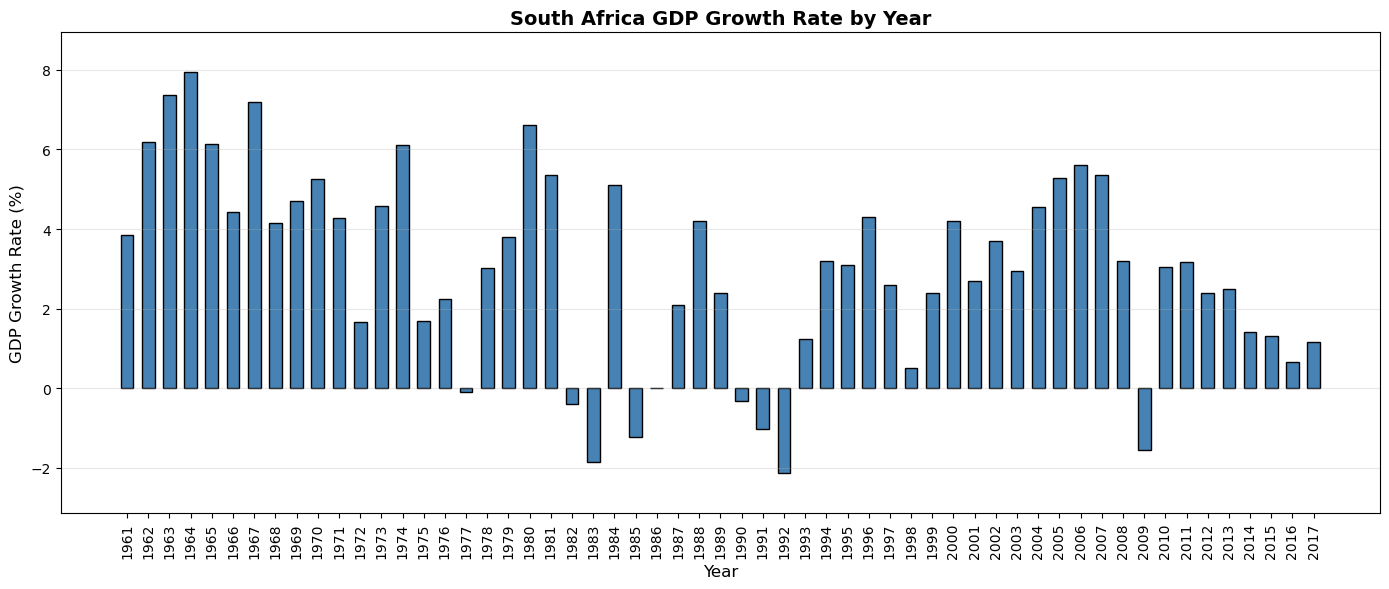

 Bar chart saved as 'bar_gdp_sa.png'


In [67]:
# BAR CHART - GDP Growth (South Africa)

# Use all years
df_all_years = df_total.copy()

plt.figure(figsize=(14, 6))

# Draw bars with proper width
plt.bar(df_all_years['Year'], df_all_years['GDP_growth'], 
        color='steelblue', edgecolor='black', linewidth=1, width=0.6)

plt.title('South Africa GDP Growth Rate by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)
plt.ylim(min(df_all_years['GDP_growth']) - 1, max(df_all_years['GDP_growth']) + 1)
plt.grid(axis='y', alpha=0.3)

# Show EVERY year on X-axis
plt.xticks(df_all_years['Year'], rotation=90)

plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/bar_gdp_sa.png', dpi=300)
plt.show()

print(" Bar chart saved as 'bar_gdp_sa.png'")

### GDP Growth by Year
A vertical bar chart was used to display South Africa's annual GDP growth rate for every year from 1961 to 2017. Bars extending above the zero line represent years of positive economic growth, while bars extending below the line represent years the economy contracted. This format was chosen because it allows individual years to be compared directly against one another and makes it immediately clear which specific years experienced the strongest growth (such as 1964, at 7.94%) and which experienced the sharpest declines (such as 1992, at -2.14%). The y-axis was adjusted to accommodate both positive and negative values so that no data would be cut off.

 ### 5. BAR CHART - Employment by Sector 

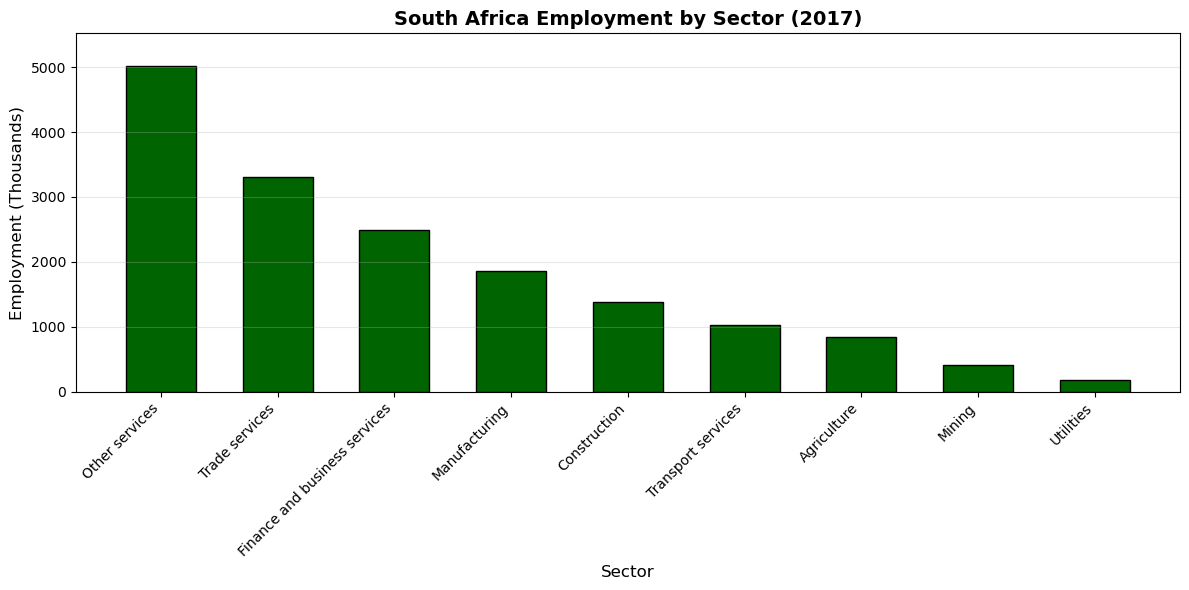

 Vertical bar chart saved as 'bar_sectors_sa.png'


In [68]:
#  BAR CHART - Employment by Sector (VERTICAL BARS)

latest_year = df_total['Year'].max()

# Filter sector data
df_sectors = df[df['TIME_PERIOD'] == latest_year].copy()
df_sectors = df_sectors[df_sectors['Sector'] != 'Sector: Total'].copy()
df_sectors['Sector_Clean'] = df_sectors['Sector'].str.replace('Sector: ', '')
df_sectors = df_sectors.sort_values('Employment_Thousands', ascending=False)

plt.figure(figsize=(12, 6))

# VERTICAL BARS 
plt.bar(df_sectors['Sector_Clean'], df_sectors['Employment_Thousands'],
        color='darkgreen', edgecolor='black', linewidth=1, width=0.6)

plt.title(f'South Africa Employment by Sector ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.ylim(0, max(df_sectors['Employment_Thousands']) * 1.1)
plt.grid(axis='y', alpha=0.3)

# Rotate labels so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/bar_sectors_sa.png', dpi=300)
plt.show()

print(" Vertical bar chart saved as 'bar_sectors_sa.png'")

### Employment by Sector
A second bar chart was used to compare total employment across South Africa's nine economic sectors for the most recent year in the dataset (2017). Sectors were sorted from highest to lowest employment so the chart reads clearly from left to right, immediately highlighting Other Services and Trade Services as the largest employers, and Utilities and Mining as the smallest. Starting the axis at zero ensures the bar heights give a fair and accurate visual comparison between sectors.

### 6. LINE CHART - GDP Trend 

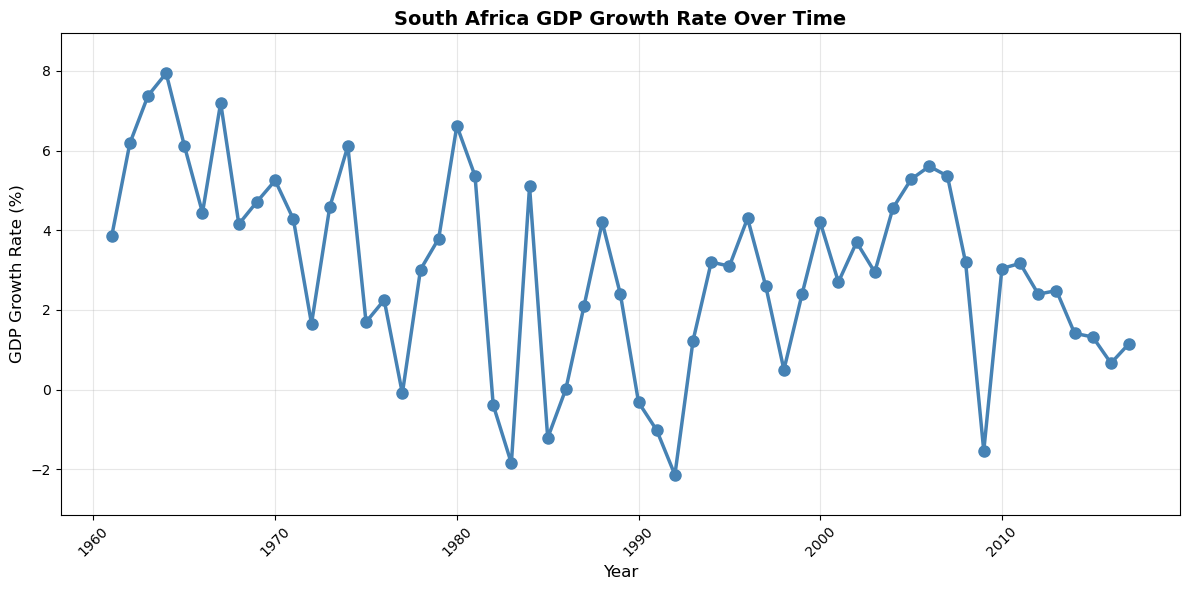

 Line chart saved as 'line_gdp_sa.png'


In [69]:
#  LINE CHART - GDP Trend (Matches Employment Graph Style)

plt.figure(figsize=(12, 6))

# Plot ALL years with line and markers
plt.plot(df_total['Year'], df_total['GDP_growth'], 
         marker='o', linestyle='-', linewidth=2.5, color='steelblue', markersize=8)

plt.title('South Africa GDP Growth Rate Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)

# Let Y-axis show negative values (GDP can be negative)
y_min = df_total['GDP_growth'].min() - 1
y_max = df_total['GDP_growth'].max() + 1
plt.ylim(y_min, y_max)

plt.grid(alpha=0.3)

# Rotate x labels 45 degrees (SAME AS EMPLOYMENT)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/line_gdp_sa.png', dpi=300)
plt.show()

print(" Line chart saved as 'line_gdp_sa.png'")

### GDP Growth Over Time
A line chart with markers was used to trace the year-by-year movement of GDP growth across the full 57-year period. Unlike the bar chart, the continuous line makes longer-term movement easier to follow, showing periods of stronger growth alongside more volatile stretches where growth dipped or turned negative. This chart is useful for spotting overall trends and turning points rather than isolated yearly values.

### 7. LINE CHART - Employment Trend 

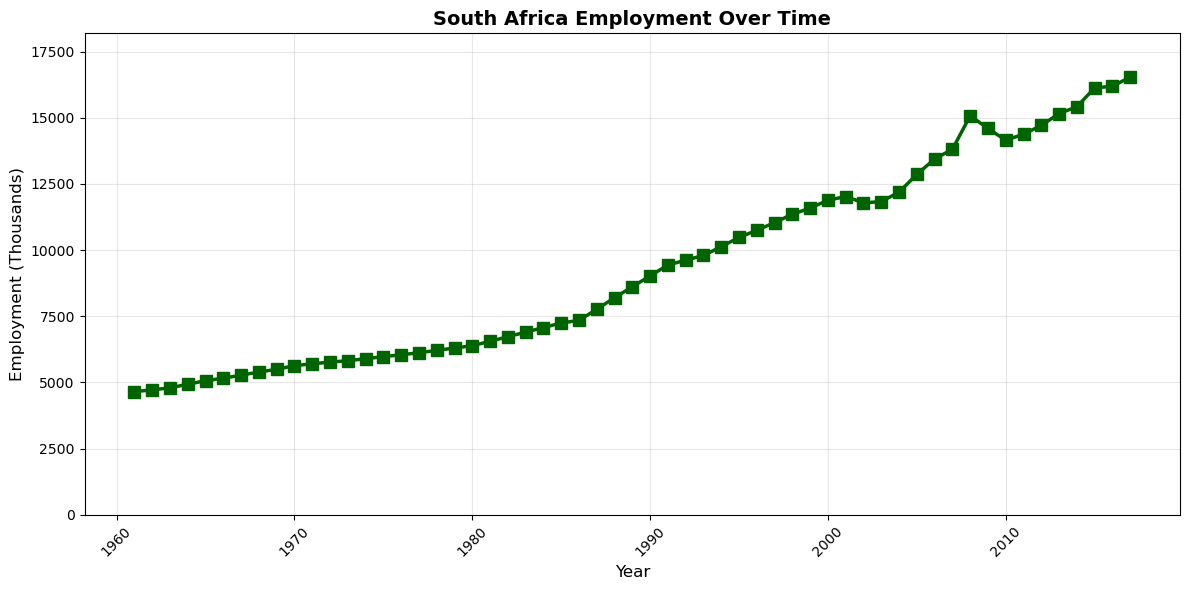

 Employment line chart saved as 'line_employment_sa.png'


In [70]:
# INE CHART - Employment Trend (South Africa)

plt.figure(figsize=(12, 6))
plt.plot(df_total['Year'], df_total['Employment'], 
         marker='s', linestyle='-', linewidth=2.5, color='darkgreen', markersize=8)

plt.title('South Africa Employment Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.ylim(0, max(df_total['Employment']) * 1.1)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/line_employment_sa.png', dpi=300)
plt.show()

print(" Employment line chart saved as 'line_employment_sa.png'")

### Employment Over Time
Similarly, a line chart was used to track total employment from 1961 to 2017. The chart shows a broadly upward trend over time, reflecting the long-term growth of South Africa's population and economy across more than five decades, although the rate of increase is not perfectly smooth and includes periods of slower growth.

### 8. PIE CHART - Employment by Sector

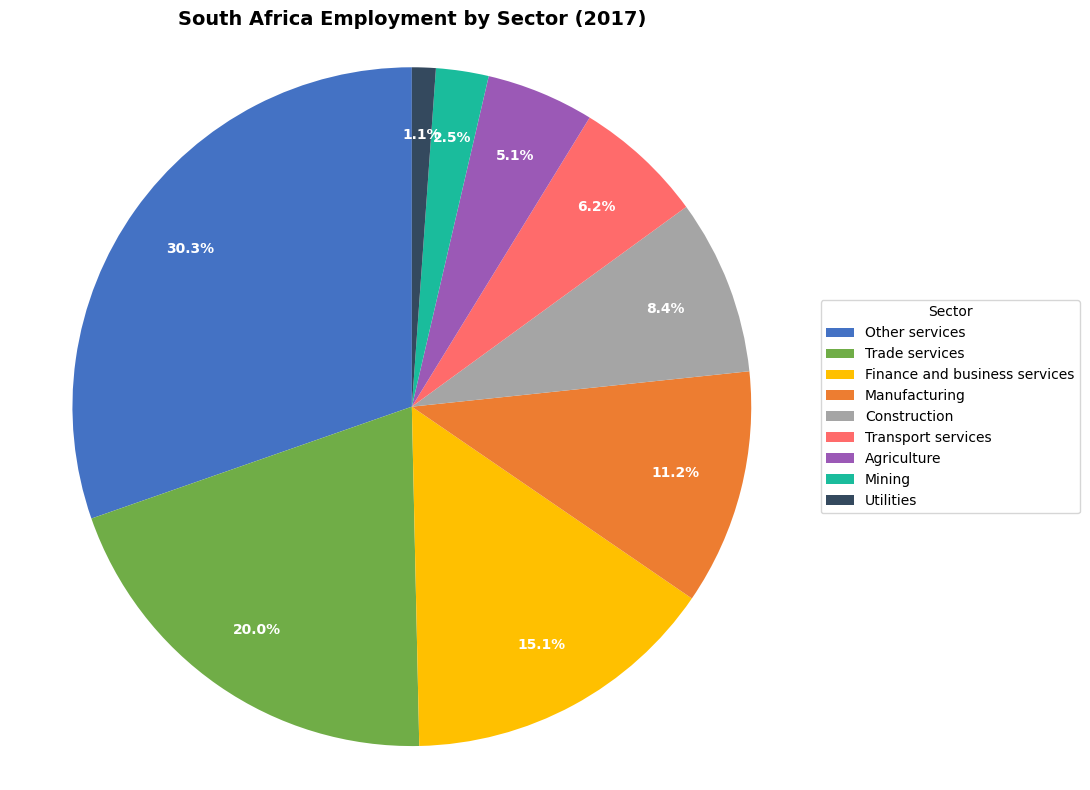

 Pie chart saved as 'pie_sectors_sa.png'


In [71]:
#PIE CHART - Employment by Sector (South Africa)

latest_year = df_total['Year'].max()
df_sectors = df[df['TIME_PERIOD'] == latest_year].copy()
df_sectors = df_sectors[df_sectors['Sector'] != 'Sector: Total'].copy()
df_sectors['Sector_Clean'] = df_sectors['Sector'].str.replace('Sector: ', '')
df_sectors = df_sectors.sort_values('Employment_Thousands', ascending=False)

plt.figure(figsize=(11, 8))

# pie chart with percentages only on slices (no on-slice name labels, to avoid overlap on small slices)
wedges, texts, autotexts = plt.pie(
    df_sectors['Employment_Thousands'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    colors=['#4472C4', '#70AD47', '#FFC000', '#ED7D31', '#A5A5A5', '#FF6B6B', '#9B59B6', '#1ABC9C', '#34495E']
)


for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Sector names shown as a legend on the side instead of on the slices themselves,
# so small slices (like Utilities and Mining) never overlap with their labels
plt.legend(wedges, df_sectors['Sector_Clean'],
           title="Sector",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10)

plt.title(f'South Africa Employment by Sector ({latest_year})', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/pie_sectors_sa.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Pie chart saved as 'pie_sectors_sa.png'")


### Employment by Sector
A pie chart was used to show each sector's share of total 2017 employment as a percentage of the whole. Other Services accounts for the largest share at 30.3%, followed by Trade Services at 20.0% and Finance and Business Services at 15.1%. At the other end of the scale, Utilities makes up just 1.1% and Mining 2.5% of total employment. A legend was placed alongside the chart rather than labelling each slice directly, so that the smaller slices remain easy to read without their labels overlapping.

### 9. SCATTER PLOT - GDP vs Employment 


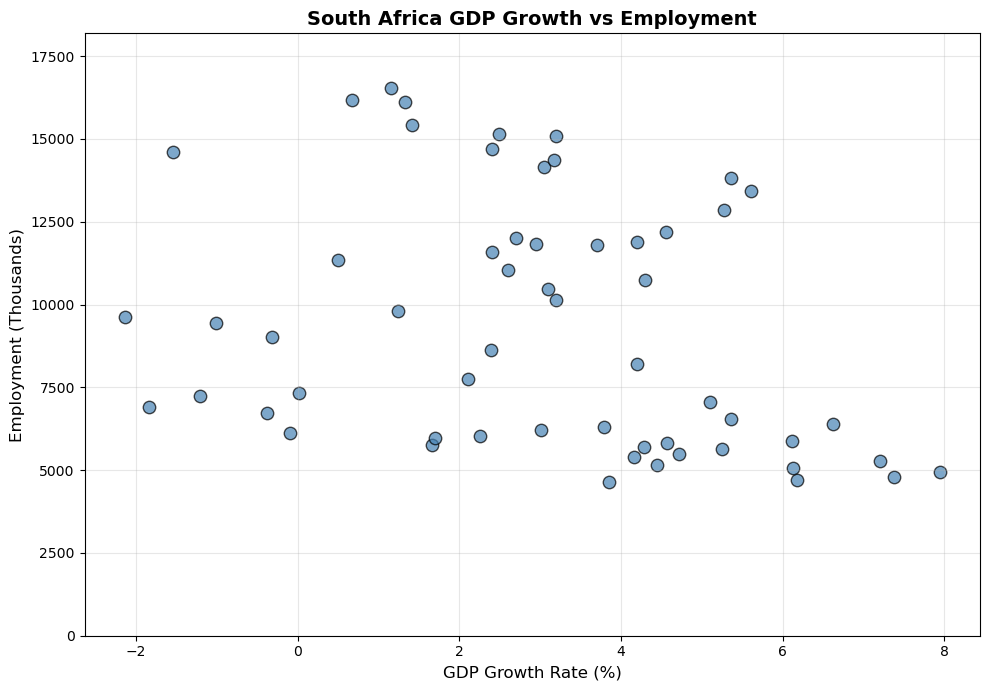

 Scatter plot saved as 'scatter_gdp_employment_sa.png'


In [72]:
# SCATTER PLOT - GDP vs Employment (South Africa)

plt.figure(figsize=(10, 7))
plt.scatter(df_total['GDP_growth'], df_total['Employment'],
            color='steelblue', s=80, alpha=0.7, edgecolors='black')

plt.title('South Africa GDP Growth vs Employment', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth Rate (%)', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.xlim(df_total['GDP_growth'].min() - 0.5, df_total['GDP_growth'].max() + 0.5)
plt.ylim(0, max(df_total['Employment']) * 1.1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/scatter_gdp_employment_sa.png', dpi=300)
plt.show()

print(" Scatter plot saved as 'scatter_gdp_employment_sa.png'")

### GDP Growth vs Employment
A scatter plot was used to plot each year's GDP growth rate against that year's total employment figure, with each dot representing one year. This chart is used to visually check whether the two variables move together in any consistent pattern. The points in this dataset appear widely scattered with a slight downward tendency, visually supporting the weak negative correlation coefficient (-0.30) calculated in the numerical analysis.


### 10. Correlation Verification

To confirm the correlation coefficient referenced above, it is calculated here using two methods: NumPy's built-in np.corrcoef() function, and the Pearson correlation formula applied manually. Both approaches produce the same result, confirming the calculation is correct

In [73]:
# Correlation Verification - GDP Growth vs Employment

x = df_total['GDP_growth']
y = df_total['Employment']

x_mean = np.mean(x)
y_mean = np.mean(y)

numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))

correlation = numerator / denominator

print(f"Correlation coefficient (calculated manually): {correlation:.4f}")
print(f"Correlation coefficient (using np.corrcoef):    {np.corrcoef(x, y)[0, 1]:.4f}")

Correlation coefficient (calculated manually): -0.2975
Correlation coefficient (using np.corrcoef):    -0.2975


### 11. Histogram - Distribution of GDP Growth



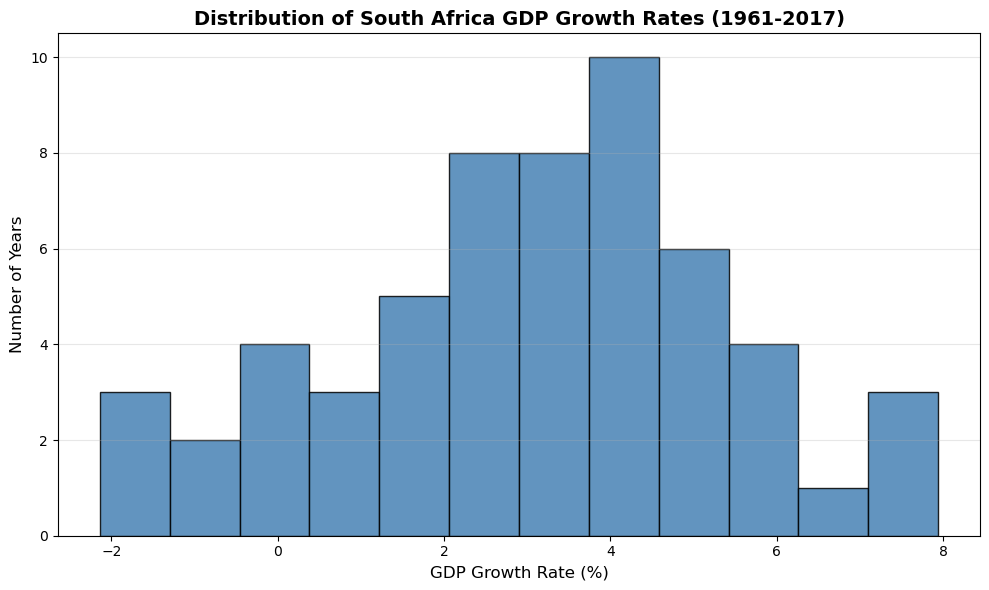

 Histogram saved as 'hist_gdp_sa.png'


In [74]:
# HISTOGRAM - Distribution of GDP Growth (South Africa)

plt.figure(figsize=(10, 6))

plt.hist(df_total['GDP_growth'], bins=12, color='steelblue', edgecolor='black', alpha=0.85)

plt.title('Distribution of South Africa GDP Growth Rates (1961-2017)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth Rate (%)', fontsize=12)
plt.ylabel('Number of Years', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/hist_gdp_sa.png', dpi=300)
plt.show()

print(" Histogram saved as 'hist_gdp_sa.png'")


### Distribution of GDP Growth
A histogram was used to group all 57 years of GDP growth data into ranges and count how many years fall into each range. This shows that GDP growth most commonly falls between roughly 2% and 5%, with fewer years experiencing very low, negative, or very high growth, indicating that while the economy has had some volatile years, typical annual growth has been moderate and broadly consistent.

### 11. Box Plot - Employment Distribution by Sector


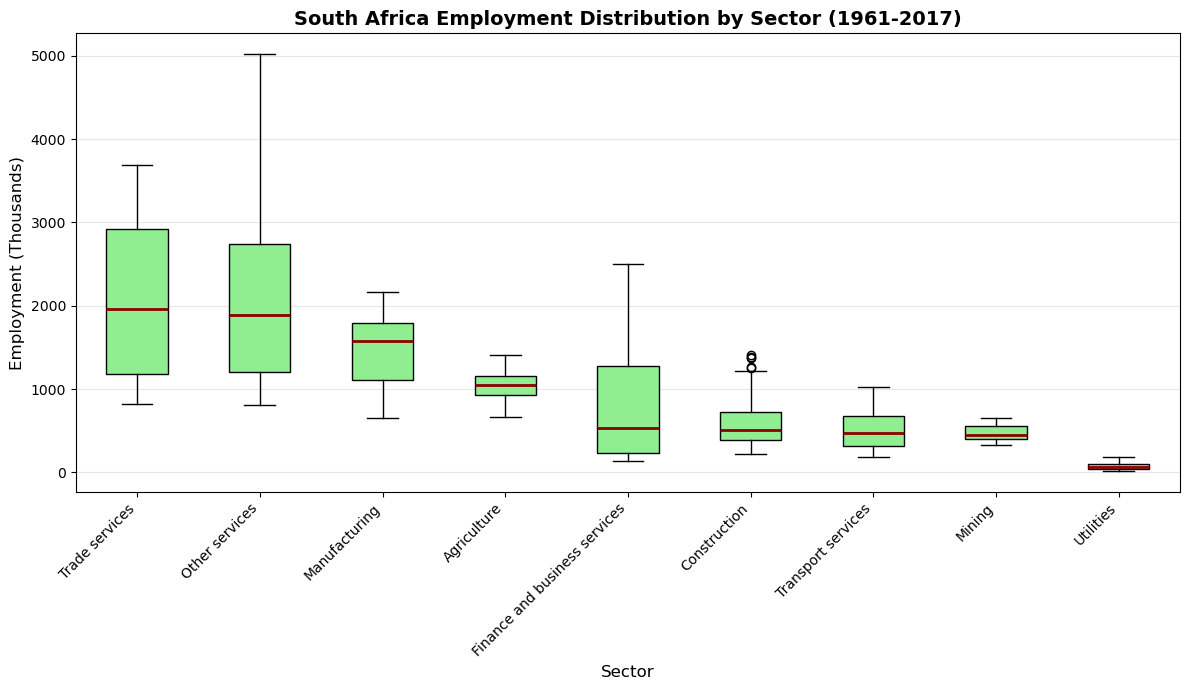

 Box plot saved as 'box_sectors_sa.png'


In [75]:
 # BOX PLOT - Employment Distribution by Sector (South Africa)

df_all_sectors = df[df['Sector'] != 'Sector: Total'].copy()
df_all_sectors['Sector_Clean'] = df_all_sectors['Sector'].str.replace('Sector: ', '')

# Order sectors by median employment for a cleaner chart
sector_order = (
    df_all_sectors.groupby('Sector_Clean')['Employment_Thousands']
    .median()
    .sort_values(ascending=False)
    .index
)

data_by_sector = [
    df_all_sectors[df_all_sectors['Sector_Clean'] == sector]['Employment_Thousands']
    for sector in sector_order
]

plt.figure(figsize=(12, 7))

plt.boxplot(data_by_sector, tick_labels=sector_order, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='darkred', linewidth=2))

plt.title('South Africa Employment Distribution by Sector (1961-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('deliverables/03_visualisation/images/box_sectors_sa.png', dpi=300)
plt.show()

print(" Box plot saved as 'box_sectors_sa.png'")


### Employment Distribution by Sector
A box plot was used to compare the full spread of employment values within each sector across all years, rather than just a single year. This chart clearly shows that Trade Services and Other Services not only have the highest typical (median) employment levels but also the widest spread, reflecting substantial growth in these sectors over time. In contrast, Utilities shows almost no spread and sits close to zero throughout, while Construction shows a couple of individual outlier years that fall notably outside its usual range.




## Summary and  Key Findings

South Africa's GDP growth between 1961 and 2017 averaged around 3.02% per year, with a median of 3.10%, showing that growth has generally been positive and relatively moderate rather than extreme. The strongest year of growth was 1964, at 7.94%, while the weakest was 1992, at -2.14%. The histogram supports this pattern, showing that most years cluster in the 2-5% growth range, with only a small number of years falling into negative or unusually high territory. This suggests that although the South African economy has experienced periods of volatility, sustained deep contractions have been relatively rare over this period.

Employment tells a different story to GDP growth. Rather than being spread evenly across the economy, employment is heavily concentrated in a small number of sectors: Other Services and Trade Services together account for more than half of all employment (30.3% and 20.0% respectively), while Utilities and Mining together make up under 4%. The box plot reinforces this, showing that Trade Services and Other Services have both the highest median employment and the widest range of values over time, meaning these sectors have grown the most and the most consistently, while smaller sectors like Utilities have remained small and stable throughout the entire period.

When GDP growth and employment are compared directly in the scatter plot, a weak negative relationship can be seen, and this is confirmed numerically by a correlation coefficient of -0.30. This indicates that years with higher GDP growth were mildly associated with lower national employment, though the relationship is far from strong. This suggests that GDP growth is not a strong direct predictor of employment levels, and that other longer-term, sector-specific structural factors — such as the ongoing growth of the services sector — likely play a larger role.

Taken together, these visualisations tell a consistent story: South Africa's GDP growth has fluctuated moderately over the decades without any extreme long-term collapse, while employment has followed its own steadier, upward path shaped primarily by which sectors are largest, rather than by year-to-year economic performance. This is an important insight for the group's overall analysis, as it suggests that policies aimed purely at boosting short-term GDP growth may not be sufficient on their own to directly grow employment, and that sector-level factors deserve closer attention.


---
# 4. Database Integration
---

## Question 4: Database Integration


## Introduction


This section demonstrates database integration for the South African GDP growth and employment dataset. A SQLite database is used to store the cleaned dataset in a structured, queryable format.

The process covers:
- Creating a database table with an appropriate schema
- Loading the cleaned CSV data into the database, with error handling
- Querying the database using several different SQL techniques (basic selection, aggregation, subqueries, and filtering)
- Safely updating and deleting records using parameterised queries
- Loading the database contents back into Pandas for further analysis
- Exporting the final data back out to CSV

This shows that the dataset can move reliably between file storage, a relational database, and Python for analysis — rather than existing only as a static spreadsheet.

#### 4.1 Connecting 

In [76]:
import sqlite3
import csv

In [77]:
conn = sqlite3.connect("GDP_Employment_South_Africa.db")
cursor = conn.cursor()

#### 4.2 Creating a table

In [78]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS gdp_employment (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    country TEXT,
    year INTEGER,
    gdp_growth REAL,
    employment_thousands REAL,
    sector TEXT
)
''')
conn.commit()

####  4.3 Loading the CSV into the table (with error handling)

In [79]:
try:
    with open('data/final_clean/GDP_Employment_South_Africa_Cleaned.csv', 'r') as file:
        csv_reader = csv.reader(file)
        next(csv_reader)  # skip header row

        for row in csv_reader:
            cursor.execute('''
                INSERT INTO gdp_employment (country, year, gdp_growth, employment_thousands, sector)
                VALUES (?, ?, ?, ?, ?)
            ''', row)

    conn.commit()
    print("Data loaded successfully.")

except FileNotFoundError:
    print("Error: CSV file not found. Check the path.")
except sqlite3.Error as e:
    print(f"Database error: {e}")

Data loaded successfully.


![Database schema](deliverables/04_database_integration/images/schema_screenshot.png)

#### 4.4 Query the database (different query types)

##### Basic select

In [80]:
cursor.execute("SELECT * FROM gdp_employment LIMIT 5")
for row in cursor.fetchall():
    print(row)

(1, 'South Africa', 2017, 1.157946951817351, 16536.302734375, 'Total')
(2, 'South Africa', 2017, 1.157946951817351, 849.6207731755255, 'Agriculture')
(3, 'South Africa', 2017, 1.157946951817351, 414.533397544058, 'Mining')
(4, 'South Africa', 2017, 1.157946951817351, 1855.8184205482744, 'Manufacturing')
(5, 'South Africa', 2017, 1.157946951817351, 187.1115981720818, 'Utilities')


![Database schema](deliverables/04_database_integration/images/basic.png)

##### Aggregate query (Average employment per sector)

In [81]:
cursor.execute('''
    SELECT sector, ROUND(AVG(employment_thousands), 2) AS avg_employment
    FROM gdp_employment
    GROUP BY sector
    ORDER BY avg_employment DESC
''')
for row in cursor.fetchall():
    print(row)

('Total', 9352.85)
('Sector: Total', 9352.85)
('Sector: Other services', 2232.17)
('Other services', 2232.17)
('Trade services', 2071.34)
('Sector: Trade services', 2071.34)
('Sector: Manufacturing', 1473.76)
('Manufacturing', 1473.76)
('Sector: Agriculture', 1039.69)
('Agriculture', 1039.69)
('Sector: Finance and business services', 831.6)
('Finance and business services', 831.6)
('Sector: Construction', 642.53)
('Construction', 642.53)
('Transport services', 515.61)
('Sector: Transport services', 515.61)
('Sector: Mining', 473.72)
('Mining', 473.72)
('Utilities', 76.44)
('Sector: Utilities', 72.42)


![Database schema](deliverables/04_database_integration/images/avg_employment.png)

In [82]:
cursor.execute('''
    SELECT year, gdp_growth
    FROM gdp_employment
    WHERE sector = 'Total'
    AND gdp_growth > (
        SELECT AVG(gdp_growth) FROM gdp_employment WHERE sector = 'Total'
    )
    ORDER BY year
''')
for row in cursor.fetchall():
    print(row)

(1961, 3.8447341417408873)
(1961, 3.8447341417408873)
(1962, 6.177930850427458)
(1962, 6.177930850427458)
(1963, 7.373709248772229)
(1963, 7.373709248772229)
(1964, 7.939608644806768)
(1964, 7.939608644806768)
(1965, 6.122798096014421)
(1965, 6.122798096014421)
(1966, 4.438386089468892)
(1966, 4.438386089468892)
(1967, 7.196523065141065)
(1967, 7.196523065141065)
(1968, 4.153372982933462)
(1968, 4.153372982933462)
(1969, 4.715902867222411)
(1969, 4.715902867222411)
(1970, 5.248661431182924)
(1970, 5.248661431182924)
(1971, 4.278934402969824)
(1971, 4.278934402969824)
(1973, 4.571944746372708)
(1973, 4.571944746372708)
(1974, 6.111122103721883)
(1974, 6.111122103721883)
(1979, 3.7905192640578207)
(1979, 3.7905192640578207)
(1980, 6.62058342724157)
(1980, 6.62058342724157)
(1981, 5.360791059640448)
(1981, 5.360791059640448)
(1984, 5.099151630014774)
(1984, 5.099151630014774)
(1988, 4.2001096483818685)
(1988, 4.2001096483818685)
(1994, 3.20000000297172)
(1994, 3.20000000297172)
(1995, 3.1

![Database schema](deliverables/04_database_integration/images/sub_query.png)

##### Filtered query - GDP growth trend for a specific sector

In [83]:
cursor.execute('''
    SELECT year, gdp_growth
    FROM gdp_employment
    WHERE sector = 'Sector: Total'
    ORDER BY year
''')
rows = cursor.fetchall()
print(rows[:5])

[(1961, 3.8447341417408873), (1962, 6.177930850427458), (1963, 7.373709248772229), (1964, 7.939608644806768), (1965, 6.122798096014421)]


![Database schema](deliverables/04_database_integration/images/specific_sector.png)

#### 4.5 Updating records safely (parameterized, not string-formatted)

In [84]:
sectors = [row[0] for row in cursor.execute("SELECT DISTINCT sector FROM gdp_employment")]

for s in sectors:
    clean = s.replace("Sector: ", "")
    cursor.execute(
        "UPDATE gdp_employment SET sector = ? WHERE sector = ?",
        (clean, s)
    )

conn.commit()
print("Sector labels cleaned.")

Sector labels cleaned.


#### 4.6 Deleting records safely

In [85]:
cursor.execute("SELECT COUNT(*) FROM gdp_employment WHERE employment_thousands IS NULL OR employment_thousands = 0")
print("Rows to delete:", cursor.fetchone()[0])

cursor.execute("DELETE FROM gdp_employment WHERE employment_thousands IS NULL")
conn.commit()
print(f"{cursor.rowcount} rows deleted.")

Rows to delete: 0
0 rows deleted.


In [86]:
cursor.execute("DELETE FROM gdp_employment WHERE sector = 'Utilities' AND year < 1965")
conn.commit()
print(f"{cursor.rowcount} rows deleted.")

4 rows deleted.


#### 4.7 Loading the database back into Pandas

In [87]:
import pandas as pd

df = pd.read_sql_query("SELECT * FROM gdp_employment", conn)
print(df.shape)
df.head()

(1698, 6)


,id,country,year,gdp_growth,employment_thousands,sector
0,1,South Africa,2017,1.157947,16536.302734,Total
1,2,South Africa,2017,1.157947,849.620773,Agriculture
2,3,South Africa,2017,1.157947,414.533398,Mining
3,4,South Africa,2017,1.157947,1855.818421,Manufacturing
4,5,South Africa,2017,1.157947,187.111598,Utilities


#### 4.8 Exporting & closing

In [88]:
df.to_csv("gdp_employment_from_db.csv", index=False)
conn.close()
print("Exported and connection closed.")

Exported and connection closed.


## Conclusion

This section successfully built a working SQLite database from the cleaned South African GDP and employment dataset. A table was created with an appropriate schema, and all rows from the cleaned CSV file were loaded in successfully, with error handling in place in case the source file could not be found.

Several types of SQL queries were demonstrated on the database: a basic selection, an aggregate query calculating average employment per sector, a subquery identifying years with above-average GDP growth, and a filtered query tracking GDP growth over time for a specific sector. Records were also updated safely — cleaning the sector labels using parameterised queries rather than raw string formatting — and outdated records (Utilities sector data before 1965) were safely deleted, removing 4 rows.

Finally, the cleaned database contents were loaded back into a Pandas DataFrame and exported to CSV, confirming that data can move reliably between the database and the rest of the analysis pipeline. This fulfils the assignment's requirement to build and query a database, update and delete records safely, and load database data into Pandas.

---
# 5. Python/Excel Data Analysis
---

# Question 5: Excel/Python Analysis of South African GDP Growth and Employment

## Purpose of the Analysis

This analysis examines the relationship between South Africa's economic growth and employment across different economic sectors from 1961 to 2017.

The cleaned dataset contains South African GDP growth and employment data. Python is used to prepare, analyse and visualise the data in order to identify trends, patterns and relationships between GDP growth and employment.

The analysis focuses on:
- GDP growth over time
- Employment across economic sectors
- Employment trends over time
- The relationship between GDP growth and total employment
- Key findings from the combined datasets

## 1. Import libraries & load the cleaned dataset

In [89]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned South African dataset
file_path = "data/final_clean/GDP_Employment_South_Africa_Cleaned.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print("Shape:", df.shape)
except FileNotFoundError:
    print(f"Error: Could not find the file at '{file_path}'.")
    print("Please make sure the notebook is running from the repository root folder.")
    raise

df.head()

Dataset loaded successfully.
Shape: (570, 5)


,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,South Africa,2017,1.157947,16536.302734,Sector: Total
1,South Africa,2017,1.157947,849.620773,Sector: Agriculture
2,South Africa,2017,1.157947,414.533398,Sector: Mining
3,South Africa,2017,1.157947,1855.818421,Sector: Manufacturing
4,South Africa,2017,1.157947,187.111598,Sector: Utilities


## 2.Verify the cleaned dataset


In [90]:
# Verify the cleaned dataset

print("===== DATASET VERIFICATION =====")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nCountries:")
print(df["REF_AREA_LABEL"].unique())

print("\nNumber of countries:")
print(df["REF_AREA_LABEL"].nunique())

print("\nYears:")
print(df["TIME_PERIOD"].min(), "to", df["TIME_PERIOD"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSectors:")
print(df["Sector"].unique())

===== DATASET VERIFICATION =====

Shape:
(570, 5)

Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Countries:
['South Africa']

Number of countries:
1

Years:
1961 to 2017

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicate rows:
0

Sectors:
['Sector: Total' 'Sector: Agriculture' 'Sector: Mining'
 'Sector: Manufacturing' 'Sector: Utilities' 'Sector: Construction'
 'Sector: Trade services' 'Sector: Transport services'
 'Sector: Finance and business services' 'Sector: Other services']


## 3. Prepare the data for analysis
### 3.1 Clean the sector names

In [91]:
# Clean the sector names for easier analysis and presentation

df["Sector_Name"] = df["Sector"].str.replace("Sector: ", "", regex=False)

print("===== CLEANED SECTOR NAMES =====")
print(df[["Sector", "Sector_Name"]].drop_duplicates().to_string(index=False))


===== CLEANED SECTOR NAMES =====
                               Sector                   Sector_Name
                        Sector: Total                         Total
                  Sector: Agriculture                   Agriculture
                       Sector: Mining                        Mining
                Sector: Manufacturing                 Manufacturing
                    Sector: Utilities                     Utilities
                 Sector: Construction                  Construction
               Sector: Trade services                Trade services
           Sector: Transport services            Transport services
Sector: Finance and business services Finance and business services
               Sector: Other services                Other services


### 3.2 Yearly GDP data




In [92]:
# Create a yearly GDP dataset

gdp_by_year = (
    df[["TIME_PERIOD", "GDP_Growth"]]
    .drop_duplicates()
    .sort_values("TIME_PERIOD")
    .reset_index(drop=True)
)

print("===== YEARLY GDP DATA =====")
print("Number of yearly GDP observations:", len(gdp_by_year))
print("First year:", gdp_by_year["TIME_PERIOD"].min())
print("Last year:", gdp_by_year["TIME_PERIOD"].max())

gdp_by_year.head()

===== YEARLY GDP DATA =====
Number of yearly GDP observations: 57
First year: 1961
Last year: 2017


,TIME_PERIOD,GDP_Growth
0,1961,3.844734
1,1962,6.177931
2,1963,7.373709
3,1964,7.939609
4,1965,6.122798


### 3.3 Yearly total employment data


In [93]:
# Create a yearly total employment dataset

employment_by_year = (
    df[df["Sector_Name"] == "Total"]
    [["TIME_PERIOD", "Employment_Thousands"]]
    .sort_values("TIME_PERIOD")
    .reset_index(drop=True)
)

print("===== YEARLY TOTAL EMPLOYMENT DATA =====")
print("Number of yearly employment observations:", len(employment_by_year))
print("First year:", employment_by_year["TIME_PERIOD"].min())
print("Last year:", employment_by_year["TIME_PERIOD"].max())

employment_by_year.head()

===== YEARLY TOTAL EMPLOYMENT DATA =====
Number of yearly employment observations: 57
First year: 1961
Last year: 2017


,TIME_PERIOD,Employment_Thousands
0,1961,4653.677246
1,1962,4716.896973
2,1963,4795.137207
3,1964,4930.197754
4,1965,5064.761230


## 4. Analyse GDP Growth
### 4.1 GDP growth statistics

In [94]:
# Analyse GDP growth over time

print("===== GDP GROWTH ANALYSIS =====")

print("\nNumber of yearly GDP observations:", len(gdp_by_year))

print("\nAverage GDP growth:")
print(round(gdp_by_year["GDP_Growth"].mean(), 2), "%")

print("\nHighest GDP growth:")
highest_gdp = gdp_by_year.loc[gdp_by_year["GDP_Growth"].idxmax()]
print("Year:", int(highest_gdp["TIME_PERIOD"]))
print("GDP growth:", round(highest_gdp["GDP_Growth"], 2), "%")

print("\nLowest GDP growth:")
lowest_gdp = gdp_by_year.loc[gdp_by_year["GDP_Growth"].idxmin()]
print("Year:", int(lowest_gdp["TIME_PERIOD"]))
print("GDP growth:", round(lowest_gdp["GDP_Growth"], 2), "%")

print("\nGDP growth summary:")
print(gdp_by_year["GDP_Growth"].describe())

===== GDP GROWTH ANALYSIS =====

Number of yearly GDP observations: 57

Average GDP growth:
3.02 %

Highest GDP growth:
Year: 1964
GDP growth: 7.94 %

Lowest GDP growth:
Year: 1992
GDP growth: -2.14 %

GDP growth summary:
count    57.000000
mean      3.023583
std       2.431271
min      -2.137033
25%       1.413826
50%       3.100000
75%       4.571945
max       7.939609
Name: GDP_Growth, dtype: float64


##  5. GDP Growth Over Time Chart

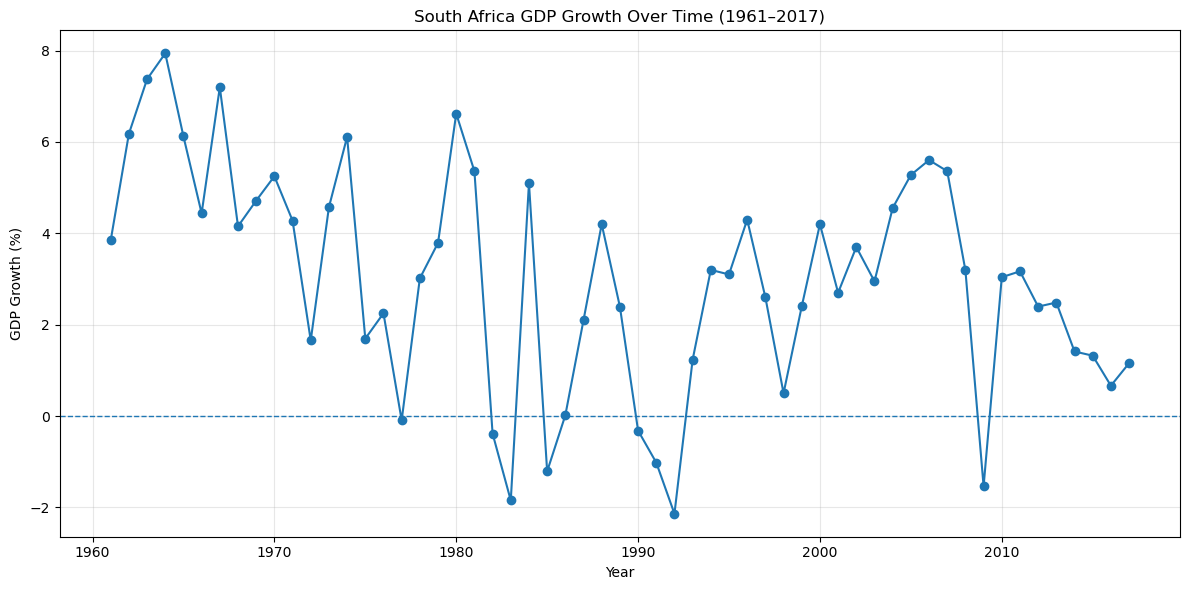

In [95]:
# Chart 1: GDP Growth Over Time

plt.figure(figsize=(12, 6))

plt.plot(
    gdp_by_year["TIME_PERIOD"],
    gdp_by_year["GDP_Growth"],
    marker="o",
    linewidth=1.5
)

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("South Africa GDP Growth Over Time (1961–2017)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6.Analyse Employment by Economic Sector.
### 6.1  Calculate average employment by sector

In [96]:
# Analyse average employment by economic sector

sector_employment = (
    df[df["Sector_Name"] != "Total"]
    .groupby("Sector_Name")["Employment_Thousands"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sector_employment.columns = [
    "Sector",
    "Average_Employment_Thousands"
]

print("===== AVERAGE EMPLOYMENT BY SECTOR =====")
print(sector_employment.to_string(index=False))

===== AVERAGE EMPLOYMENT BY SECTOR =====
                       Sector  Average_Employment_Thousands
               Other services                   2232.169429
               Trade services                   2071.336669
                Manufacturing                   1473.759850
                  Agriculture                   1039.694930
Finance and business services                    831.599820
                 Construction                    642.529747
           Transport services                    515.611710
                       Mining                    473.721739
                    Utilities                     72.421918


### 6.2 Employment by Economic Sector Chart


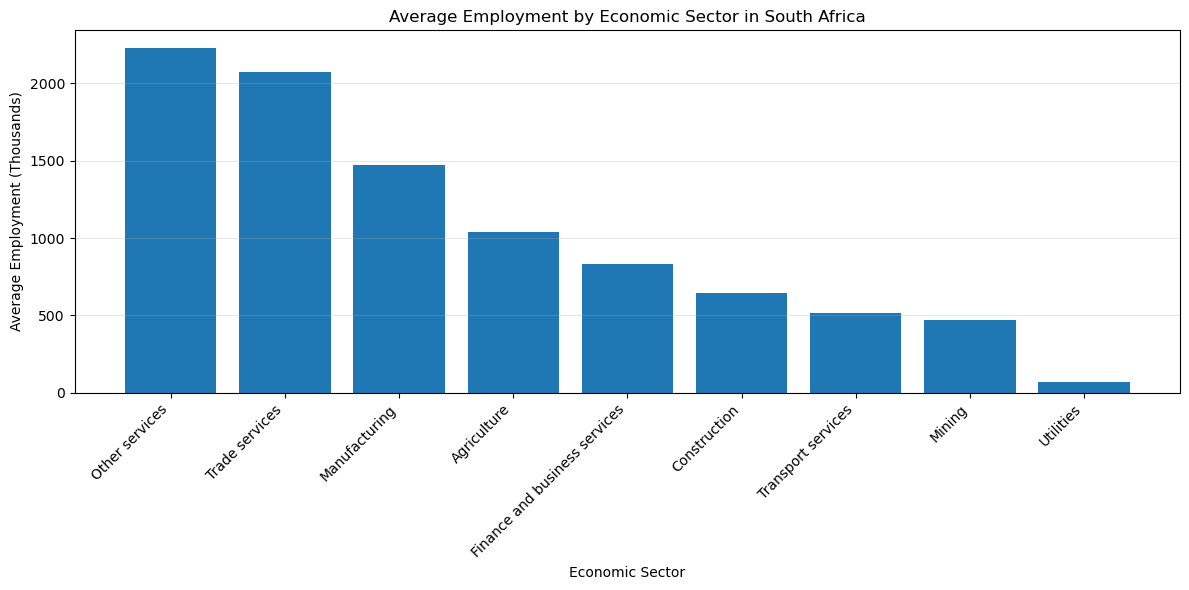

In [97]:
# Chart 2: Average Employment by Economic Sector

plt.figure(figsize=(12, 6))

plt.bar(
    sector_employment["Sector"],
    sector_employment["Average_Employment_Thousands"]
)

plt.title("Average Employment by Economic Sector in South Africa")
plt.xlabel("Economic Sector")
plt.ylabel("Average Employment (Thousands)")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Analyse Total Employment Over Time.
### 7.1 Analyse employment over time

In [98]:
# Analyse total employment over time

print("===== TOTAL EMPLOYMENT OVER TIME =====")

print("Number of yearly employment observations:", len(employment_by_year))
print("First year:", employment_by_year["TIME_PERIOD"].min())
print("Last year:", employment_by_year["TIME_PERIOD"].max())

print("\nEmployment summary statistics:")
print(employment_by_year["Employment_Thousands"].describe())

print("\nFirst 5 years:")
print(employment_by_year.head().to_string(index=False))

print("\nLast 5 years:")
print(employment_by_year.tail().to_string(index=False))

===== TOTAL EMPLOYMENT OVER TIME =====
Number of yearly employment observations: 57
First year: 1961
Last year: 2017

Employment summary statistics:
count       57.000000
mean      9352.845823
std       3736.307765
min       4653.677246
25%       5972.548340
50%       8615.634766
75%      12022.030273
max      16536.302734
Name: Employment_Thousands, dtype: float64

First 5 years:
 TIME_PERIOD  Employment_Thousands
        1961           4653.677246
        1962           4716.896973
        1963           4795.137207
        1964           4930.197754
        1965           5064.761230

Last 5 years:
 TIME_PERIOD  Employment_Thousands
        2013          15159.450195
        2014          15415.942383
        2015          16130.101562
        2016          16188.352539
        2017          16536.302734


### 7.2 Total Employment Over Time.

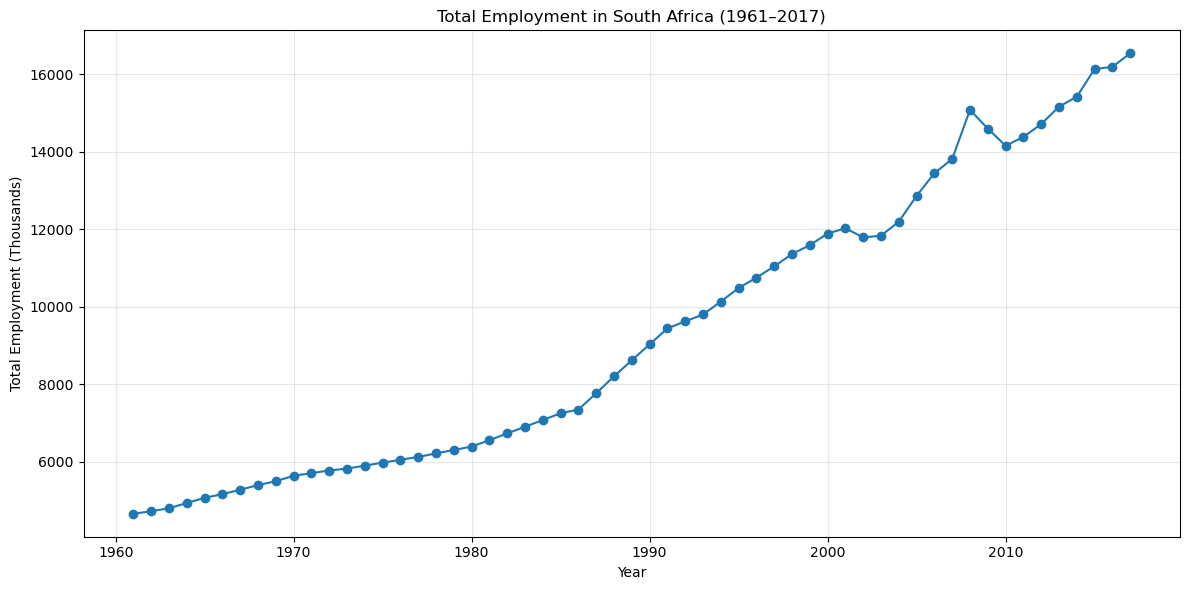

In [99]:
# Chart 3: Total Employment Over Time

plt.figure(figsize=(12, 6))

plt.plot(
    employment_by_year["TIME_PERIOD"],
    employment_by_year["Employment_Thousands"],
    marker="o",
    linewidth=1.5
)

plt.title("Total Employment in South Africa (1961–2017)")
plt.xlabel("Year")
plt.ylabel("Total Employment (Thousands)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. GDP Growth and Employment Together
### 8.1 Combine the two analyses

In [100]:
# Combine GDP growth and total employment by year

gdp_employment = pd.merge(
    gdp_by_year,
    employment_by_year,
    on="TIME_PERIOD",
    how="inner"
)

print("===== GDP GROWTH AND EMPLOYMENT =====")
print("Number of observations:", len(gdp_employment))

print("\nFirst 5 observations:")
print(gdp_employment.head().to_string(index=False))

print("\nLast 5 observations:")
print(gdp_employment.tail().to_string(index=False))

===== GDP GROWTH AND EMPLOYMENT =====
Number of observations: 57

First 5 observations:
 TIME_PERIOD  GDP_Growth  Employment_Thousands
        1961    3.844734           4653.677246
        1962    6.177931           4716.896973
        1963    7.373709           4795.137207
        1964    7.939609           4930.197754
        1965    6.122798           5064.761230

Last 5 observations:
 TIME_PERIOD  GDP_Growth  Employment_Thousands
        2013    2.485468          15159.450195
        2014    1.413826          15415.942383
        2015    1.321862          16130.101562
        2016    0.664552          16188.352539
        2017    1.157947          16536.302734


### 8.2 Calculate the correlation between GDP growth and total employment.

In [101]:
# Calculate the correlation between GDP growth and total employment

correlation = gdp_employment[
    ["GDP_Growth", "Employment_Thousands"]
].corr().loc["GDP_Growth", "Employment_Thousands"]


print("===== GDP GROWTH AND EMPLOYMENT CORRELATION =====")
print("Correlation:", round(correlation, 4))


===== GDP GROWTH AND EMPLOYMENT CORRELATION =====
Correlation: -0.2975


### 8.3 Visualise the relationship between GDP Growth and Employment.

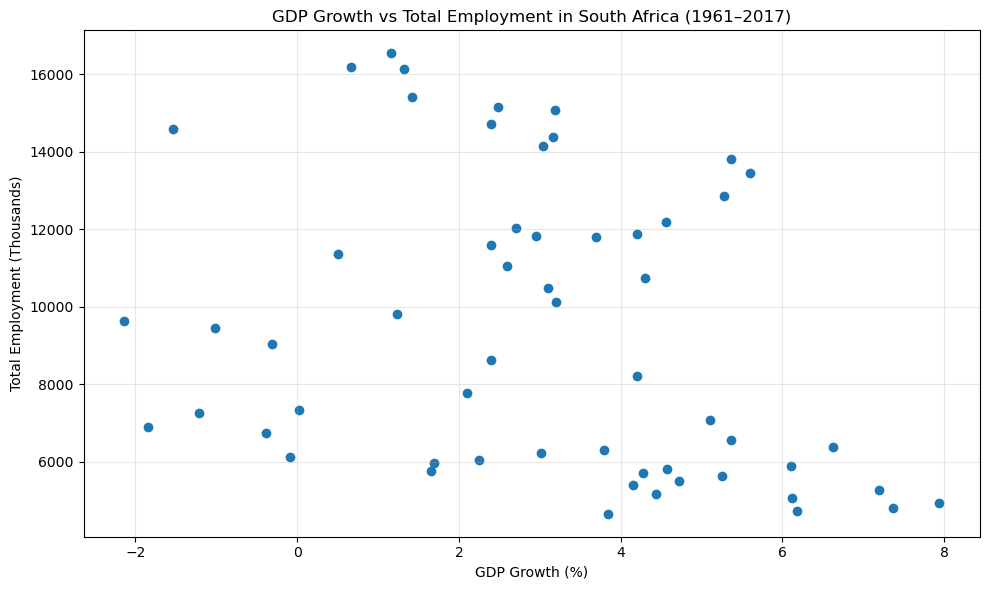

In [102]:
# Chart 4: GDP Growth vs Total Employment

plt.figure(figsize=(10, 6))

plt.scatter(
    gdp_employment["GDP_Growth"],
    gdp_employment["Employment_Thousands"]
)

plt.title("GDP Growth vs Total Employment in South Africa (1961–2017)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Total Employment (Thousands)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9. Conditional Formatting

In [103]:
# Conditional formatting: Average Employment by Sector

formatted_sector_employment = (
    sector_employment.style
    .background_gradient(
        subset=["Average_Employment_Thousands"],
        cmap="YlGn"
    )
    .format({
        "Average_Employment_Thousands": "{:,.2f}"
    })
)

formatted_sector_employment

,Sector,Average_Employment_Thousands
0,Other services,"2,232.17"
1,Trade services,"2,071.34"
2,Manufacturing,"1,473.76"
3,Agriculture,"1,039.69"
4,Finance and business services,831.60
5,Construction,642.53
6,Transport services,515.61
7,Mining,473.72
8,Utilities,72.42


# Key Findings
### GDP Growth
* South Africa recorded an average GDP growth rate of approximately **3.02%** between 1961 and 2017.
* The highest GDP growth in the dataset was approximately **7.94% in 1964**.
* The lowest GDP growth was approximately **-2.14% in 1992**, showing that the economy experienced periods of negative growth.
* The GDP growth chart shows considerable variation in economic performance across the period.
### Employment by Economic Sector
* **Other services** recorded the highest average employment at approximately **2,232.17 thousand**.
* **Trade services** had the second-highest average employment at approximately **2,071.34 thousand**.
* **Utilities** recorded the lowest average employment at approximately **72.42 thousand**.
* This shows that employment was distributed unevenly across South Africa's economic sectors.
### Employment Over Time
* Total employment increased substantially from approximately **4,653.68 thousand in 1961** to approximately **16,536.30 thousand in 2017**.
* The overall employment trend was upward, although some periods showed declines, particularly around the late 2000s and early 2010s.
### Relationship Between GDP Growth and Employment
* The correlation between GDP growth and total employment was approximately **-0.2975**.
* This indicates a **weak negative linear relationship** between the two variables during the period studied.
* The result suggests that annual GDP growth and the total employment level did not move together in a strong simple linear pattern.
* The correlation should not be interpreted as evidence that GDP growth causes employment to decrease.
* Overall, employment increased substantially over the long term, while annual GDP growth fluctuated considerably

## Conclusion

The analysis of South African GDP growth and employment from 1961 to 2017 shows that GDP growth fluctuated considerably over the period, while total employment increased substantially over the long term. The average GDP growth was approximately 3.02%.

Employment was concentrated mainly in Other services, Trade services, Manufacturing, and Agriculture, while Utilities had the lowest average employment.

The correlation between annual GDP growth and total employment was -0.2975, indicating a weak negative linear relationship. This suggests that annual GDP growth and employment did not move together in a simple or consistent pattern during the period analysed.

Overall, the findings show that higher annual GDP growth did not automatically result in higher employment in the same period. Employment trends can be influenced by other economic and structural factors, meaning that GDP growth and employment should not be assumed to have a direct one-to-one relationship.

---
# Overall Project Findings and Conclusion
---

This notebook combined five stages of analysis — data preparation, NumPy numerical analysis, visualisation, database integration, and Python/Excel analysis — all working from the same cleaned South African GDP growth and employment dataset (1961–2017). Bringing these sections together produces one consistent picture of South Africa's economic performance.

**GDP Growth:** Across every section of this notebook, GDP growth averaged approximately 3.02% per year, with the highest growth recorded in 1964 (7.94%) and the lowest in 1992 (-2.14%). These figures were independently confirmed multiple times — through NumPy statistics, the visualisation histogram, and SQL queries run directly against the database — with identical results each time, confirming the data was cleaned and carried through correctly at every stage.

**Employment:** Employment was consistently shown to be concentrated in a small number of sectors rather than spread evenly across the economy. Other Services and Trade Services recorded the highest average employment throughout the analysis, while Utilities recorded the lowest. This pattern held true whether measured through NumPy's sector-level statistics, the visualisation charts (bar, pie, and box plot), or the database's aggregate SQL queries — the same sectors led and lagged in every version of the analysis.

**Relationship Between GDP Growth and Employment:** The correlation between annual GDP growth and total employment was calculated independently in three separate sections of this notebook — the NumPy analysis, the visualisation notebook's verification cell, and the Python/Excel analysis — and all three produced the same result: approximately -0.30, a weak negative relationship. This consistency across independently written code gives confidence that the result is genuine and not a calculation error, and it points to a real and interesting finding: short-term GDP growth does not reliably predict short-term employment levels in South Africa.

**Conclusion:** Taken together, these five deliverables tell one coherent story: South Africa's GDP growth has fluctuated moderately over more than five decades without any extreme, sustained collapse, while employment followed its own steadier, long-term upward path — shaped far more by which sectors are structurally largest than by year-to-year economic performance. This suggests that policies focused purely on boosting short-term GDP growth are unlikely, on their own, to directly translate into higher employment, and that sector-specific structural factors deserve closer attention. This is the central insight the two datasets reveal when analysed together.

---
# 6. Report & Demo
---

The full written report (7-9 pages, covering dataset details, methods, visualisations, and conclusions) is submitted separately as a DOCX/PDF.